# The first approach to any EDA process is to understand the table content and structure

### Target tables:

- SalesOrderHeader: financial focuses on revenue, orders, dates and customers
- SalesOrderDetails: financial focuses in line items, products, quantities, prices
- Product: financial focuses on Products, prices and costs
- ProductCategory: focuses on product category
- ProductSubCategory: a support column to access ProductCategory column from Product table
- ShipMethod: focuses on different means of transport
- SalesTerritory: highlighting quality spatial data 
- SpecialOffer: product sell discount
- Customers: customers and business entities
- CurrencyRateID: support table to track CurrencyRateID converted currency (base operational currency, not global universal currency)

### these tables focuses on extracting potentional `operational` and `customer-based` insights for the business benefit
- it appears I would require more tables to extract real insights, the sheer value and scale of this database is both rich and massive, I underestimated time required to do so, whereby the sales section connect with product, customers, spatial data. thus the viable option is to add tables as needed to deliver a quality summary of generated insights

In [1]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from urllib.parse import quote_plus
from sqlalchemy import create_engine

load_dotenv()

db_user = os.getenv('DB_USER')
db_host = os.getenv('DB_HOST')
encoded_password = quote_plus(os.getenv('DB_PASSWORD'))
encoded_name = quote_plus(os.getenv('DB_NAME'))

connection_string = f'mysql+pymysql://{db_user}:{encoded_password}@{db_host}/{encoded_name}'
engine = create_engine(connection_string)

with engine.connect() as connection:
    
    # extracting salesorderheader table
    query_orderheader = 'SELECT * FROM `aw2022-sales-salesorderheader`'
    df_orderheader = pd.read_sql_query(query_orderheader, connection)

    # extracting salesorderdetails table
    query_orderdetails = 'SELECT * FROM `aw2022-sales-salesorderdetails`'
    df_orderdetails = pd.read_sql_query(query_orderdetails, connection)

    # extracting salesterritory table
    query_salesterritory = 'SELECT * FROM `aw2022-sales-salesterritory`'
    df_salesterritory = pd.read_sql_query(query_salesterritory, connection)

    # extracting shipment method table
    query_shipment = 'SELECT * FROM `aw2022-purchasing-shipmethod`'
    df_shipment = pd.read_sql_query(query_shipment, connection)

    # extracting product table
    query_product = 'SELECT * FROM `aw2022-production-product`'
    df_product = pd.read_sql_query(query_product, connection)

    # extracting product category
    query_product_category = 'SELECT * FROM `aw2022-production-productcategory`'
    df_product_category = pd.read_sql_query(query_product_category, connection)

    # extracting product subcategory
    query_product_subcategory = 'SELECT * FROM `aw2022-production-productsubcategory`'
    df_product_subcategory = pd.read_sql_query(query_product_subcategory, connection)

    # extracting special offer
    query_product_specialoffer = 'SELECT * FROM `aw2022-sales-specialoffer`'
    df_sales_specialoffer= pd.read_sql_query(query_product_specialoffer, connection)

    # extracting customers
    query_customers = 'SELECT * FROM `aw2022-sales-customer`'
    df_customers = pd.read_sql_query(query_customers, connection)

    # extracting customers
    query_currencyrate = 'SELECT * FROM `aw2022-sales-currencyrate`'
    df_currencyrate = pd.read_sql_query(query_currencyrate, connection)

## A robust query design must:

- save sensitive variables in .env
- encode strings before reaching the DB connection string
- include a parameter dictionary as a guardrail against SQL injection
- align with business goals as to not overengineer the task and overcomplicate it

### for our case, we wouldn't include the third option as we are handling manual EDA and not an automated pipeline for a live service

In [2]:
df_orderheader.head(3)

,SalesOrderID,RevisionNumber,OrderDate,DueDate,ShipDate,Status,OnlineOrderFlag,SalesOrderNumber,PurchaseOrderNumber,AccountNumber,...,CreditCardID,CreditCardApprovalCode,CurrencyRateID,SubTotal,TaxAmt,Freight,TotalDue,Comment,rowguid,ModifiedDate
0,43659,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43659,PO522145787,10-4020-000676,...,16281.0,105041Vi84182,NaN,20565.6206,1971.5149,616.0984,23153.2339,None,{79B65321-39CA-4115-9CBA-8FE0903E12E6},2011-06-07
1,43660,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43660,PO18850127500,10-4020-000117,...,5618.0,115213Vi29411,NaN,1294.2529,124.2483,38.8276,1457.3288,None,{738DC42D-D03B-48A1-9822-F95A67EA7389},2011-06-07
2,43661,8,2011-05-31,2011-06-12,2011-06-07,5,FALSE,SO43661,PO18473189620,10-4020-000442,...,1346.0,85274Vi6854,4.0,32726.4786,3153.7696,985.5530,36865.8012,None,{D91B9131-18A4-4A11-BC3A-90B6F53E9D74},2011-06-07


In [3]:
df_orderheader.shape

(31465, 26)

In [4]:
df_orderheader.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   SalesOrderID            31465 non-null  int64         
 1   RevisionNumber          31465 non-null  int64         
 2   OrderDate               31465 non-null  datetime64[us]
 3   DueDate                 31465 non-null  datetime64[us]
 4   ShipDate                31465 non-null  datetime64[us]
 5   Status                  31465 non-null  int64         
 6   OnlineOrderFlag         31465 non-null  str           
 7   SalesOrderNumber        31465 non-null  str           
 8   PurchaseOrderNumber     3806 non-null   str           
 9   AccountNumber           31465 non-null  str           
 10  CustomerID              31465 non-null  int64         
 11  SalesPersonID           3806 non-null   float64       
 12  TerritoryID             31465 non-null  int64         
 1

## it appears the next columns contain null values:

- `PurchaseOrderNumber`
- `SalesPersonID`
- `CreditCardID`
- `CreditCardApprovalCode`
- `CurrencyRateID`

In [5]:
for col, ratio in zip(df_orderheader.columns, df_orderheader.isna().mean()):
    if ratio == 0:
        continue
    else:
        print(f'{col}, null_ratio: {ratio*100:.2f}%')


PurchaseOrderNumber, null_ratio: 87.90%
SalesPersonID, null_ratio: 87.90%
CreditCardID, null_ratio: 3.59%
CreditCardApprovalCode, null_ratio: 3.59%
CurrencyRateID, null_ratio: 55.58%
Comment, null_ratio: 100.00%


## Generated insights from nan_ratios:
- 88% missing values in `SalePersonID` and `PurchaseOrderNumber` allows to define an intial assumption that 88% of sales transactions were online orders
- 4% null ratio in `CreditCardID` and `CreditCardApprovalCode` means that 4% of orders were paid using cash or other paying mediums whereby a massive ratio of 96% of transactions were paid using a credit card
    - it interestingly align with our first insight whom assumes 88% of sales were online orders, we will calculate the `OnlineFlagRatio` to confirm this assumption
- for the `TerritoryID` column, it appears that almost **38.27%** of transactions happened in the local market (domestic), whereby **61.73%** of transactions happened in foreign markets
- looking closely at `CurrencyRateID`, within the the domestic transactions share, most of currency conversion rate which represents ~2% of transactions in the domestic market currency was converted into Canadian dollars suggesting that some customers in canada tend to buy the products within the US and got it shipped back to canada, whereby in the foreign transactions share our top 3 foreign regions transactions are **Australia**, **Canada** and **United Kingdom**, whereby the least transactions regions are in **France** followed by **Germany**

In [6]:
foreign_domestic_market = df_orderheader[['TerritoryID', 'CurrencyRateID']].copy()
territory_subset = df_salesterritory.drop(columns=['rowguid', 'ModifiedDate']).copy()

territory_mapping = pd.merge(foreign_domestic_market, territory_subset, on='TerritoryID')

domestic_share = territory_mapping[
    (territory_mapping['TerritoryID'].isin([1, 2, 3, 4, 5]))]

foreign_share = territory_mapping[
    (~territory_mapping['TerritoryID'].isin([1, 2, 3, 4, 5]))]

foreign_transactions = foreign_share.shape[0]
domestic_transactions = domestic_share.shape[0]

domestic_share_ratio = np.round((domestic_transactions / (foreign_transactions + domestic_transactions))*100, 2)
domestic_share_ratio

np.float64(38.27)

In [7]:
domestic_currencyrate = territory_mapping[
    (territory_mapping['TerritoryID'].isin([1, 2, 3, 4, 5])) &
    (territory_mapping['CurrencyRateID'].notna())]

foreign_currencyrate = territory_mapping[
    (~territory_mapping['TerritoryID'].isin([1, 2, 3, 4, 5])) &
    (territory_mapping['CurrencyRateID'].isna())]

ls_check = list(domestic_currencyrate['CurrencyRateID'].astype(int))

check = df_currencyrate[df_currencyrate['CurrencyRateID'].isin(ls_check)]['ToCurrencyCode'].value_counts()
check

ToCurrencyCode
CAD    21
Name: count, dtype: int64

- most currency rate exchange in the domestic market represent 2% which are all in canadian dollars (CAD) suggesting that a small portion of customers in canada directly bought the products from the US market

In [8]:
foreign_transactions_ratios = territory_mapping[~territory_mapping['TerritoryID'].isin([1, 2, 3, 4, 5])][['Name', 'TerritoryID']].value_counts()

foreign_currencyrate_ratio = foreign_transactions_ratios / foreign_transactions_ratios.sum()
foreign_currencyrate_ratio

Name            TerritoryID
Australia       9              0.352296
Canada          6              0.209380
United Kingdom  10             0.165723
France          7              0.137562
Germany         8              0.135039
Name: count, dtype: float64

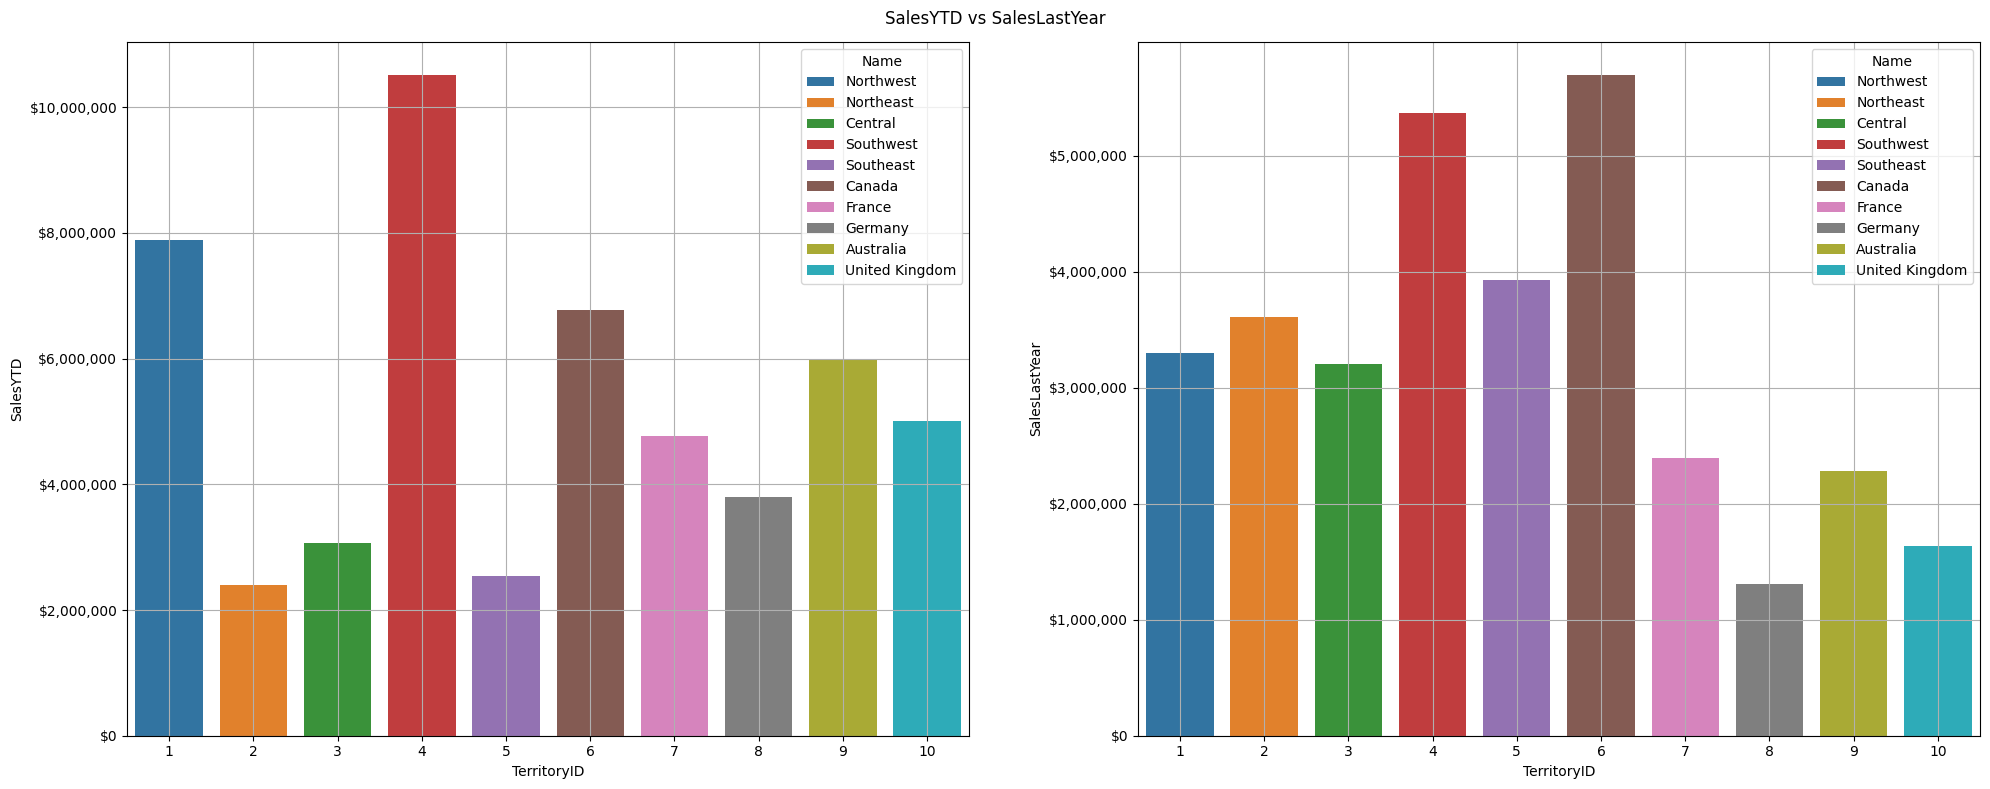

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter, FuncFormatter

region_total_spending = territory_mapping[['TerritoryID', 'SalesYTD', 'SalesLastYear', 'Name']]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.barplot(data=region_total_spending,
            x='TerritoryID',
            y='SalesYTD',
            hue='Name',
            legend=True,
            ax=axes[0])

sns.barplot(data=region_total_spending,
            x='TerritoryID',
            y='SalesLastYear',
            hue='Name',
            legend=True,
            ax=axes[1])

for ax in axes:
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))
    ax.grid(True)

plt.suptitle('SalesYTD vs SalesLastYear')
plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

#### within the foreign market transactions share:
- Australia is our top region with frequent purchases leading with ~35% of total transactions in the foreign category
- Canada is our second region with a 20% total transactions share in the foreign category
- United Kingdom with 16%
- France abd germany with ~14% where the least frequent transactions occur for our product share in the foreign category

In [10]:
true, false = df_orderheader['OnlineOrderFlag'].value_counts()

true_ratio = true / (true + false)
print(f'online_orders_ratio: {true_ratio*100:.2f}%')

online_orders_ratio: 87.90%


- Online Orders Ratio: 87.90%
- Conclusion: Our previous assumption is true; the vast majority of transactions were online orders

### in Explatory Data Analysis some columns must be `dropped` as they hold 0 to low value in the process
##### we might try to save some Null records if the ratio of missing values are relatively low and can be propagated
- columns to be removed:
    - `Comment`: an empty column
    - `rowguid`: Global Unique Identifier, doesn't add value to the EDA step
    - `ModifiedData`: data entry's date of modification, doesn't add value
    - `CreditCardID`: sensitive data, doesn't hold any value to the EDA process
    - `CreditCardApproval`: sensitive data, doesn't contribute to the EDA process
- columns to be propagated:
    - None

In [11]:
df_currencyrate

,CurrencyRateID,CurrencyRateDate,FromCurrencyCode,ToCurrencyCode,AverageRate,EndOfDayRate,ModifiedDate
0,1,2011-05-31,USD,ARS,1.0000,1.0002,2011-05-31 00:00:00
1,2,2011-05-31,USD,AUD,1.5491,1.5500,2011-05-31 00:00:00
2,3,2011-05-31,USD,BRL,1.9379,1.9419,2011-05-31 00:00:00
3,4,2011-05-31,USD,CAD,1.4641,1.4683,2011-05-31 00:00:00
4,5,2011-05-31,USD,CNY,8.2781,8.2784,2011-05-31 00:00:00
...,...,...,...,...,...,...,...
13527,13528,2014-05-27,USD,USD,1.0000,1.0000,2014-01-02 17:39:45
13528,13529,2014-05-28,USD,USD,1.0000,1.0000,2014-01-02 17:39:45
13529,13530,2014-05-29,USD,USD,1.0000,1.0000,2014-01-02 17:39:45
13530,13531,2014-05-30,USD,USD,1.0000,1.0000,2014-01-02 17:39:45


- The acronym VEB stands for the Venezuelan Bolívar, which was the official currency of Venezuela from 1879 until January 2008, which suggests that adventureworks before 2008 to 2025 was just boostrapped values with newer features for each version

In [12]:
import numpy as np

columns_to_remove = ['Comment', 'rowguid', 'ModifiedDate', 'CreditCardID', 'CreditCardApprovalCode']
refined_df_orderheader = df_orderheader.drop(columns=columns_to_remove)

temp_subset_header = refined_df_orderheader[['TerritoryID', 'CurrencyRateID', 'SalesOrderID', 'CustomerID',
                                            'SubTotal', 'TaxAmt', 'Freight', 'ShipMethodID', 'OrderDate']].copy()

# propagation NULL in CurrencyRateID with the value 13520 which represent USD currency, so further calculations such as currency normalization to dollars works
temp_subset_header['CurrencyRateID'] = temp_subset_header['CurrencyRateID'].fillna(13520)

temp_subset_currency = df_currencyrate[['CurrencyRateID', 'EndOfDayRate', 'FromCurrencyCode', 'ToCurrencyCode']].copy()
currency_header_df = pd.merge(temp_subset_header, temp_subset_currency, on='CurrencyRateID', how='left')

currency_header_df['SubTotal_USD'] = currency_header_df['SubTotal'] / currency_header_df['EndOfDayRate']
currency_header_df['TaxAmt_USD'] = currency_header_df['TaxAmt'] / currency_header_df['EndOfDayRate']
currency_header_df['Freight_USD'] = currency_header_df['Freight'] / currency_header_df['EndOfDayRate']
currency_header_df['TotalDue_USD'] = currency_header_df['SubTotal_USD'] + currency_header_df['TaxAmt_USD'] + currency_header_df['Freight_USD']

total_due_freight = (currency_header_df['Freight_USD'] + currency_header_df['SubTotal_USD'])
total_due_tax = (currency_header_df['TaxAmt_USD'] + currency_header_df['SubTotal_USD'])

# guardrails to protect against zero-value cells before calculation (defensive practice)
currency_header_df['FreightBurden%'] = np.where(
    total_due_freight > 0,
    np.round((currency_header_df['Freight_USD'] / total_due_freight*100), 2),
    0)

# guardrails to protect against zero-value cells before calculation (defensive practice)
currency_header_df['TaxRatio%'] = np.where(
    total_due_tax > 0,
    np.round((currency_header_df['TaxAmt_USD'] / total_due_tax*100), 2),
    0)

currency_header_df.head(3)

,TerritoryID,CurrencyRateID,SalesOrderID,CustomerID,SubTotal,TaxAmt,Freight,ShipMethodID,OrderDate,EndOfDayRate,FromCurrencyCode,ToCurrencyCode,SubTotal_USD,TaxAmt_USD,Freight_USD,TotalDue_USD,FreightBurden%,TaxRatio%
0,5,13520.0,43659,29825,20565.6206,1971.5149,616.0984,5,2011-05-31,1.0000,USD,USD,20565.620600,1971.514900,616.098400,23153.233900,2.91,8.75
1,5,13520.0,43660,29672,1294.2529,124.2483,38.8276,5,2011-05-31,1.0000,USD,USD,1294.252900,124.248300,38.827600,1457.328800,2.91,8.76
2,6,4.0,43661,29734,32726.4786,3153.7696,985.5530,5,2011-05-31,1.4683,USD,CAD,22288.686644,2147.905469,671.220459,25107.812572,2.92,8.79


- converted **SubTotal** currency from foreign currency to USD currency in **SubTotal_USD**, by normalizing financial data within this table, our RFM subset calculations would be unbiased and accurate

### at this step, the scope aimed to focus on aggregating Orders with higher transactions count and transactions sum, tracking and preparing to analyze customer behavior using unsupervised modeling techniques to build generative profiles
- it appears that we would need to track the customers whom placed these Orders to find the real insights, as it appears below a single transaction count per SalesOrderID represent a unique identifier per product defined by an automated system to track each unique order  
    - update: `CustomerID` was part of the table, that helped save time and helped switch the merge operation from `SalesOrderID` to `CustomerID`
> what a surprise, the FM subset is not in USD alone, but different currencies and we must normalize it back to USD format

In [13]:
Transaction_count_per_account = (
    currency_header_df.groupby('CustomerID')['SubTotal_USD']
    .count()
    .reset_index()
    .rename(columns={'SubTotal_USD': 'Transactions_count'})
)

Transaction_total_per_account = (
    currency_header_df.groupby('CustomerID')['SubTotal_USD']
    .sum()
    .reset_index()
    .rename(columns={'SubTotal_USD': 'Transactions_total'})
)

SalesID_df = pd.merge(Transaction_total_per_account, Transaction_count_per_account, on='CustomerID')

top_transactions_count = SalesID_df.sort_values(ascending=False, by='Transactions_count')
top_transactions_total = SalesID_df.sort_values(ascending=False, by='Transactions_total')

top_transactions_total.head(30)

,CustomerID,Transactions_total,Transactions_count
18818,29818,877107.192300,12
18715,29715,853849.179500,12
19050,30050,823967.960554,8
19117,30117,816755.576300,12
18701,29701,746317.529300,8
18617,29617,740985.833800,12
18646,29646,727272.649300,12
18580,29580,724299.636500,12
18827,29827,711864.762400,12
18497,29497,700803.785400,12


In [14]:
top_transactions_total['Transactions_total'].sum()

np.float64(102587093.21496052)

#### before proceeding to the unsupervised modeling layer, we are going to confirm our claim about outlier existance

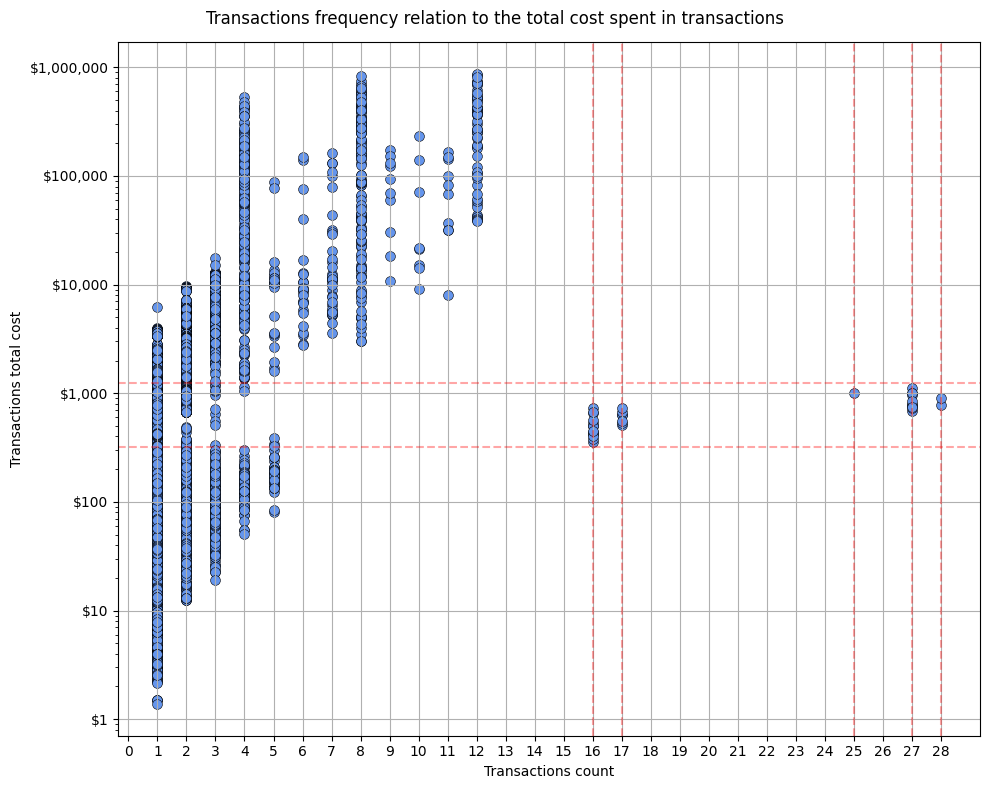

In [15]:
import matplotlib.ticker as ticker

x_sales = SalesID_df['Transactions_count']
y_sales = SalesID_df['Transactions_total']

plt.figure(figsize=(10, 8))

plt.scatter(x_sales, y_sales,
            s=50,
            linewidth=0.4,
            color='cornflowerblue',
            edgecolors='k')

plt.suptitle('Transactions frequency relation to the total cost spent in transactions')
plt.xlabel('Transactions count')
plt.ylabel('Transactions total cost')

# changed the scale into a logarithmic scale, so that y-axis won't dominate the difference between it and the x-axis
plt.yscale('log')

# changed the scientific notation into clear financial notations instead
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.xticks(np.arange(0, 29, 1))

x_cords=[16, 17, 25, 27, 28]
y_cords=[320, 1250]

for x_line in x_cords:
    plt.axvline(x=x_line,
                color='red',
                linestyle='--',
                alpha=0.35)
    
for y_line in y_cords:
    plt.axhline(y=y_line,
                color='red',
                linestyle='--',
                alpha=0.35)

plt.tight_layout()
plt.grid(True)
plt.show()

In [16]:
hypothesis_validation = top_transactions_total[(top_transactions_total['Transactions_count'] >= 16) & (top_transactions_total['Transactions_count'] <= 28)]
hypothesis_validation['Transactions_total'].describe()

count      35.000000
mean      668.903020
std       203.085969
min       357.775393
25%       506.013711
50%       668.341675
75%       784.845461
max      1119.418669
Name: Transactions_total, dtype: float64

> it appears that customers with `Transactions_count` = (16, 17, 25, 27, 28) are outliers, they won't be dropped but rather further prove that GMM is the right tool for this task
- furthermore, following the aggregated_summary output, it is visible that limiting the analysis to top 30 most paying and top 30 least paying costumers was a biased practice from my part and further assesses the need for GMM with `full` covariance type
- the x-axis *axvline* was used to track these outliers's transactions purchase frequence, while *axhline* was to track the transaction cost interval for these outliers, the above summary confirm the visualization cost interval for specific transactions count as in customers with a `Transaction_count` >= **16** have a Transaction cost between ~= **$358** and **$1120** with an average spending of ~= **$669**

In [17]:
# so total customers detected as outliers are 35
outlier_customers = hypothesis_validation.shape[0]

# total customers in the dataset are 19k
total_customers = top_transactions_total.shape[0]

outlier_customers_portion = f'{(outlier_customers / total_customers)*100:.2f}%'
outlier_customers_portion

'0.18%'

In [18]:
outlier_customers_transactions_sum = hypothesis_validation['Transactions_total'].sum()
total_transactions_sum = top_transactions_total['Transactions_total'].sum()

outlier_customers_transactions_portion = f'{(outlier_customers_transactions_sum / total_transactions_sum)*100:.2f}%'
outlier_customers_transactions_portion

'0.02%'

> these extreme outliers transactions represent about **0.18%** of total customers, suggesting that they hold no critical value to the business model, but still they hold a total of **$34501** in transaction total, representing **0.02%** of all customer transactions, but still **$34501** is still a portion that cannot be ignored if possible, further supporting the need for **GMM**

In [19]:
# calculating the taxratio before freight cost
currency_header_df['TaxRatio%'] = np.round(currency_header_df['TaxAmt_USD'] / (currency_header_df['SubTotal_USD'] + currency_header_df['TaxAmt_USD'])*100, 2)

# calculating freight ratio from `TotalDue` for further analysis
currency_header_df['FreightBurden%'] = np.round(currency_header_df['Freight_USD'] / (currency_header_df['SubTotal_USD'] + currency_header_df['Freight_USD']) * 100, 2)

currency_header_df.head(3)

,TerritoryID,CurrencyRateID,SalesOrderID,CustomerID,SubTotal,TaxAmt,Freight,ShipMethodID,OrderDate,EndOfDayRate,FromCurrencyCode,ToCurrencyCode,SubTotal_USD,TaxAmt_USD,Freight_USD,TotalDue_USD,FreightBurden%,TaxRatio%
0,5,13520.0,43659,29825,20565.6206,1971.5149,616.0984,5,2011-05-31,1.0000,USD,USD,20565.620600,1971.514900,616.098400,23153.233900,2.91,8.75
1,5,13520.0,43660,29672,1294.2529,124.2483,38.8276,5,2011-05-31,1.0000,USD,USD,1294.252900,124.248300,38.827600,1457.328800,2.91,8.76
2,6,4.0,43661,29734,32726.4786,3153.7696,985.5530,5,2011-05-31,1.4683,USD,CAD,22288.686644,2147.905469,671.220459,25107.812572,2.92,8.79


In [20]:
currency_header_df['SubTotal_USD'].describe()

count     31465.000000
mean       3260.355735
std       10858.975955
min           1.161611
25%          45.580000
50%         648.905400
75%        2174.975687
max      167140.857661
Name: SubTotal_USD, dtype: float64

### the creation of `TaxRatio%` urge the need for more spatial data, as it appears although some subtotals are low on average yet with higher tax than much larger subtotal values
- further analysis in shipment interval can be considered as indirect cause of tax increase
- further spatial data needed to evaluate a more accurate description of tax differentiation
- perhaps low subtotal have a higher tax rate on average, or different market static taxes regardless of such, we will proceed to confirm this assumption

### we will start with the first hypothesis as to confirm if low subtotal shipments have a greater taxratio on average than bigger subtotal shipments

In [21]:
min_val = currency_header_df['SubTotal'].min()
max_val = currency_header_df['SubTotal'].max()

q1 = currency_header_df['SubTotal'].quantile(0.25)
q3 = currency_header_df['SubTotal'].quantile(0.75)

categorized_labels = ['Low', 'Medium', 'High']
cohort_bins = [min_val, q1, q3, max_val]

# categorizing `SubTotal` costs into three categories to build the support our hypothesis
currency_header_df['SubTotalCategorized'] =  pd.cut(currency_header_df['SubTotal'],
                                        bins=cohort_bins,
                                        labels=categorized_labels,
                                        include_lowest=True)

currency_header_df.head(3)

,TerritoryID,CurrencyRateID,SalesOrderID,CustomerID,SubTotal,TaxAmt,Freight,ShipMethodID,OrderDate,EndOfDayRate,FromCurrencyCode,ToCurrencyCode,SubTotal_USD,TaxAmt_USD,Freight_USD,TotalDue_USD,FreightBurden%,TaxRatio%,SubTotalCategorized
0,5,13520.0,43659,29825,20565.6206,1971.5149,616.0984,5,2011-05-31,1.0000,USD,USD,20565.620600,1971.514900,616.098400,23153.233900,2.91,8.75,High
1,5,13520.0,43660,29672,1294.2529,124.2483,38.8276,5,2011-05-31,1.0000,USD,USD,1294.252900,124.248300,38.827600,1457.328800,2.91,8.76,Medium
2,6,4.0,43661,29734,32726.4786,3153.7696,985.5530,5,2011-05-31,1.4683,USD,CAD,22288.686644,2147.905469,671.220459,25107.812572,2.92,8.79,High


In [22]:
summary_subtotal_average = currency_header_df.groupby('SubTotalCategorized')['TaxRatio%'].mean()

summary_subtotal_average

SubTotalCategorized
Low       7.423910
Medium    7.503807
High      7.907203
Name: TaxRatio%, dtype: float64

In [23]:
subset_count = currency_header_df.groupby('SubTotalCategorized', observed=False)['SubTotal_USD'].count()
total_number_customers = subset_count.sum()

Low_SubTotal_Ratio = f"Low_p_customers: {subset_count['Low'] / (total_number_customers)*100:.2f}%"
Medium_SubTotal_Ratio = f"Medium_p_customers: {subset_count['Medium'] / (total_number_customers)*100:.2f}%"
High_SubTotal_Ratio = f"High_p_customers: {subset_count['High'] / (total_number_customers)*100:.2f}%"

categorized_ratio = [Low_SubTotal_Ratio, Medium_SubTotal_Ratio, High_SubTotal_Ratio]
print(categorized_ratio)

['Low_p_customers: 25.26%', 'Medium_p_customers: 49.79%', 'High_p_customers: 24.95%']


In [24]:
total = subset_count.sum()
percentages = np.round((subset_count / total)*100)

percentages

SubTotalCategorized
Low       25.0
Medium    50.0
High      25.0
Name: SubTotal_USD, dtype: float64

##  <- I highly recommend to investigate top 25% of business customers per Territory | ShipMethodID preference !!!!

- the previous cell output indicates a sample imbalance, the common feedback might be to propagate the `Low` and `High` categories or scale down the `Medium` category to balance the calculation conclusion in cell below, but I think personally that removing such is an even more biased action toward real behaviors of customer transactions, thus why leaving the mismatch as is and interpreting it is a more fair approach to classify our top/low paying customers using the quantile approach

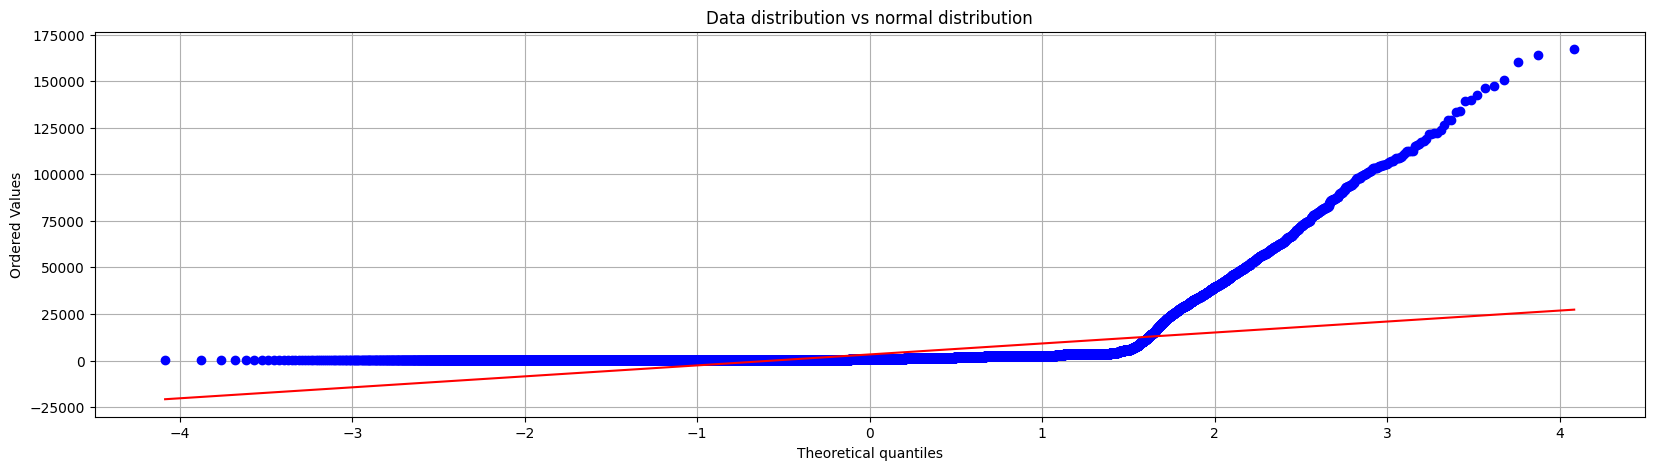

In [25]:
import matplotlib.pyplot as plt
import scipy.stats as stats

data = currency_header_df['SubTotal_USD']

plt.figure(figsize=(20, 5))

stats.probplot(data, dist='norm', plot=plt)
plt.title('Data distribution vs normal distribution')

plt.grid(True)
plt.show()

> the visualization confirms customer transaction doesn't follow a normal distribution

In [26]:
refined_subset = currency_header_df[['SubTotal_USD', 'TaxRatio%']]
refined_subset.corr(method='pearson')

,SubTotal_USD,TaxRatio%
SubTotal_USD,1.000000,0.500307
TaxRatio%,0.500307,1.000000


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold

import warnings
warnings.filterwarnings('ignore')


df_clean = refined_subset[['SubTotal_USD', 'TaxRatio%']].dropna()

X__ = df_clean[['SubTotal_USD']]
y__ = df_clean['TaxRatio%']

X_train, X_test, y_train, y_test = train_test_split(X__, y__,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=42)

linear_r = LinearRegression()
linear_r.fit(X_train, y_train)

rf_regressor = RandomForestRegressor(random_state=42)

params_grid_xgb = {
    'max_depth': [29],
    'n_estimators': [245],
    'min_samples_leaf': [9]
}

Kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# switched from GridSearchCV to RandomizedSearchCV to peek at different combinations randomly for fast checking
gs_rf = RandomizedSearchCV(
    estimator=rf_regressor,
    param_distributions=params_grid_xgb,
    n_iter=1000,
    cv=Kfold,
    scoring='r2'
)
'''
optimal_rf_hyperparameters = [
    ('n_estimators': 245),
    ('min_samples_leaf': 9),
    ('max_depth': 29)
]'''

gs_rf.fit(X_train, y_train)

gs_rf.best_params_

{'n_estimators': 245, 'min_samples_leaf': 9, 'max_depth': 29}

In [28]:
from sklearn.metrics import r2_score, root_mean_squared_error

y_pred_lr = linear_r.predict(X_test)
y_pred_rf = gs_rf.predict(X_test)

lr_r2_score = r2_score(y_test, y_pred_lr)
rf_r2_score = r2_score(y_test, y_pred_rf)

lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)

r2_summary = f'linear r2_score: {lr_r2_score*100:.2f}%\nRandomForest r2_score: {rf_r2_score*100:.2f}%\ndifference of explained variance: {(rf_r2_score - lr_r2_score)*100:.2f}%'
rmse_summary = f'\nlinear RMSE: {lr_rmse:.4f}\nRandomForest RMSE: {rf_rmse:.4f}'

print(r2_summary, rmse_summary)

linear r2_score: 20.86%
RandomForest r2_score: 41.10%
difference of explained variance: 20.24% 
linear RMSE: 0.5416
RandomForest RMSE: 0.4672


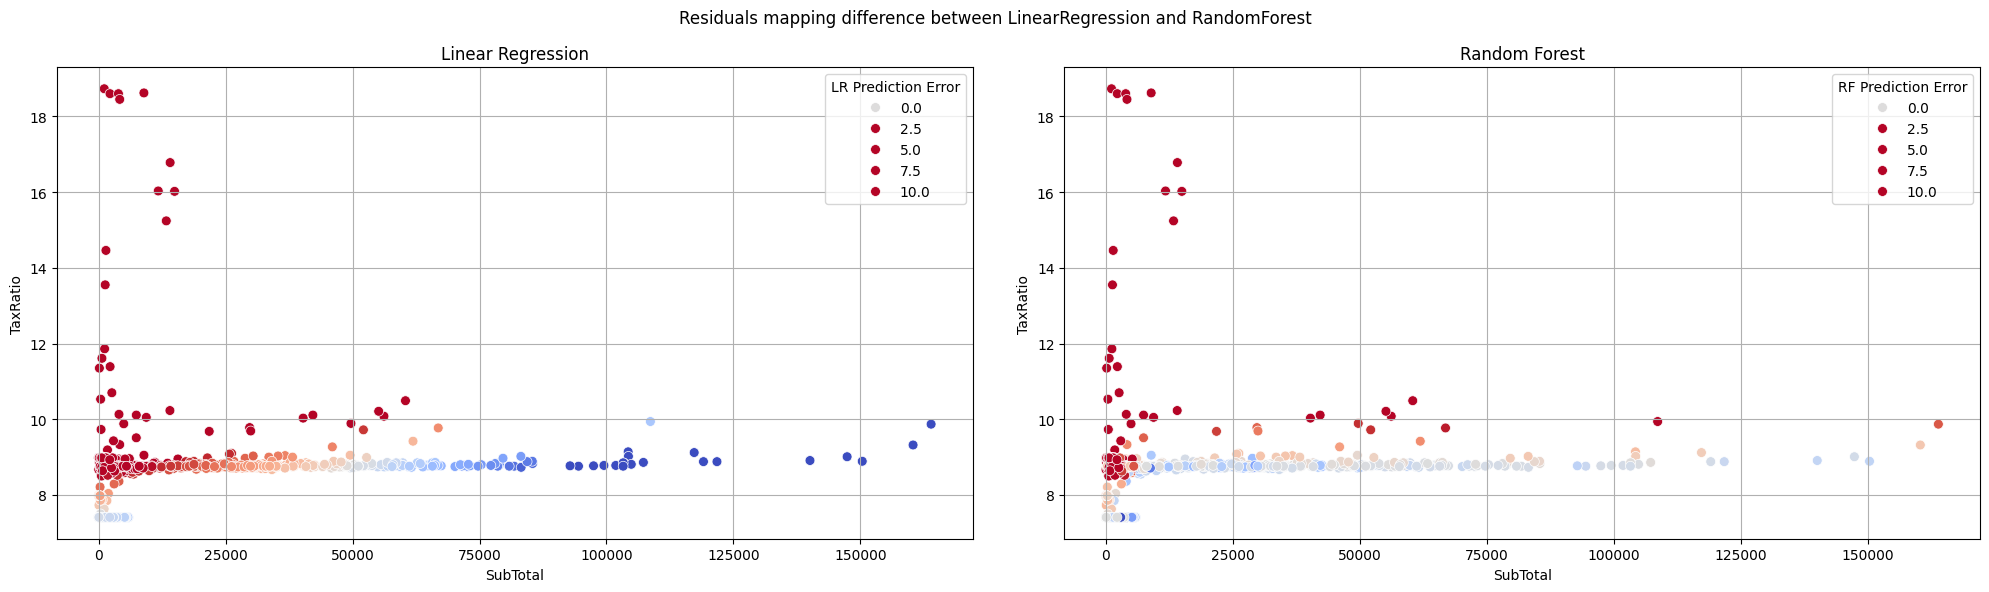

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

lr_errors = y_test - y_pred_lr
rf_errors = y_test - y_pred_rf

df_plot = pd.DataFrame({
    'SubTotal': X_test['SubTotal_USD'],
    'TaxRatio': y_test,
    'LR Prediction Error': lr_errors,
    'RF Prediction Error': rf_errors
})

# 3. Plot using Seaborn
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

sns.scatterplot(
    data=df_plot,
    x='SubTotal',
    y='TaxRatio',
    hue='LR Prediction Error',
    palette='coolwarm',       # Blue = Overpredicted, Red = Underpredicted, White/Gray = Perfect
    hue_norm=(-1, 1),         # Centers the color scale symmetrically around 0 error
    edgecolor='w',
    s=50,
    linewidth=0.5,
    ax=ax[0]
)

sns.scatterplot(
    data=df_plot,
    x='SubTotal',
    y='TaxRatio',
    hue='RF Prediction Error',
    palette='coolwarm',
    hue_norm=(-1, 1),
    edgecolor='w',
    s=50,
    linewidth=0.5,
    ax=ax[1]
)

ax[0].set_title('Linear Regression')
ax[1].set_title('Random Forest')

fig.suptitle('Residuals mapping difference between LinearRegression and RandomForest')
ax[0].grid()
ax[1].grid()

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
plt.show()

> the hypothesis that transactions with low `SubTotal` have a higher average `TaxRatio%` than transactions with higher `TaxRatio%` is proven false, furthermore the correlation matrix indicates that a correlation strenght ~= 51% represent a moderate correlation strenght between both, as this indicate that potentionally and highly likely the relationship between the two features is non-linear and further investigation is needed

- the visualization support the claim of non-linear relationship between the two features, by plotting the residuals for the two models we can clearly see **RandomForest** dominanting **LinearRegression** model as proven in the side-by-side output, further indicating that the hypothesis follows a linear increase impact on `TaxRatio%` for low `SubTotal` transactions is proven partially false, with exceptions to existing linear patterns indicating that  linear portion do indeed drive `TaxRatio%` increase or decrease

> using the output above the visualization, we clearly the R-squared outut of explained variance, comparing a linear model like **LinearRegression** to a decent non-linear model such as **RandomForestRegressor** we can say that certainly that the underlying relationship between *TaxRatio%_USD* and *SubTotal_USD* is mostly non-linear yet also contains linear patterns, thus why our pearson correlation returned a 51% correlation strength and **LinearRegression** model returned a score equal to **20.86%**. the difference between the two models explained by the difference which equal to **20.24%** meaning that the nature between the feature and the label (relationship) is highly non-linear as seen by analyzing the gap between the models, furthermore if the decent score explained at 46% by **RandomForestRegressor** suggest that the omitted features are needed to explain the label variance 

- Calculating the time interval between `OrderDate`, `ShipDate` and `DueDate` to support further hypothesis validation

In [30]:
temp_view = refined_df_orderheader[['OrderDate', 'DueDate', 'ShipDate']]

temp_view.head(5)

,OrderDate,DueDate,ShipDate
0,2011-05-31,2011-06-12,2011-06-07
1,2011-05-31,2011-06-12,2011-06-07
2,2011-05-31,2011-06-12,2011-06-07
3,2011-05-31,2011-06-12,2011-06-07
4,2011-05-31,2011-06-12,2011-06-07


- for the original table in **MySQL** Database, it appears that the values follows this format `xx-xx-xx` but for the timestamps it follows the same `00:00:00` value, as it appear from now on we can rest assured and focus on dates instead

In [31]:
# Normalizing Dtypes from timedelta64 into datetime
refined_df_orderheader['ShipDate'] = pd.to_datetime(refined_df_orderheader['ShipDate'])
refined_df_orderheader['OrderDate'] = pd.to_datetime(refined_df_orderheader['OrderDate'])
refined_df_orderheader['DueDate'] = pd.to_datetime(refined_df_orderheader['DueDate'])

refined_df_orderheader['TaxRatio%_USD'] = np.round((currency_header_df['TaxAmt_USD'] / (currency_header_df['SubTotal_USD'] + currency_header_df['TaxAmt_USD']))*100, 2)

# omitting the 'days' and leaving the values as integers
refined_df_orderheader['TimeInterval_ship'] = (
    refined_df_orderheader['ShipDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

refined_df_orderheader['TimeInterval_due'] = (
    refined_df_orderheader['DueDate'] - refined_df_orderheader['OrderDate']
    ).dt.days

# doesn't require .dt.days as we already handled it in previous the previous calculations
refined_df_orderheader['BufferTime'] = refined_df_orderheader['TimeInterval_due'] - refined_df_orderheader['TimeInterval_ship']

# copied the subset using .copy() as each time this subset is modified it appears that it confuses pandas,
# pandas isn't sure if you aim to alter this subset or the original dataframe.
time_interval_summary = refined_df_orderheader[['TimeInterval_ship', 'TimeInterval_due', 'BufferTime', 'TaxRatio%_USD']].copy()

time_interval_summary.head(3)

,TimeInterval_ship,TimeInterval_due,BufferTime,TaxRatio%_USD
0,7,12,5,8.75
1,7,12,5,8.76
2,7,12,5,8.79


In [32]:
time_interval_summary.info()

<class 'pandas.DataFrame'>
RangeIndex: 31465 entries, 0 to 31464
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TimeInterval_ship  31465 non-null  int64  
 1   TimeInterval_due   31465 non-null  int64  
 2   BufferTime         31465 non-null  int64  
 3   TaxRatio%_USD      31465 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 983.4 KB


#### testing correlation strenght between `taxratio` and other selective features

In [33]:
correlation_matrix = time_interval_summary.corr()['TaxRatio%_USD']

correlation_matrix

TimeInterval_ship    0.002025
TimeInterval_due     0.002025
BufferTime                NaN
TaxRatio%_USD        1.000000
Name: TaxRatio%_USD, dtype: float64

- it appeared, that `TimeInterval_ship` and `TimeInterval_due` doesn't correlate with `TaxRatio%` increase, we also notice that `BufferTime` returned **NaN**

In [34]:
for i in time_interval_summary['BufferTime'].unique():
    print(i)

5


In [35]:
np.var(time_interval_summary['BufferTime'])

np.float64(0.0)

### Operational Insight: Uniform Logistics Execution Across Tax zones:
- Finding: Statistical correlation between `BufferTime` and `TaxRatio` returned **NaN**, driven by total absense in the variance in the buffer window, with a single outlier of **5 days** in 31,465 transactions
- Conclusion: Fullfillment scheduling is entirely uniform. Regional tax rates differences has no impact on delivery expectation and logistics timeline

### Let's visualize the correlation matrix in our target table

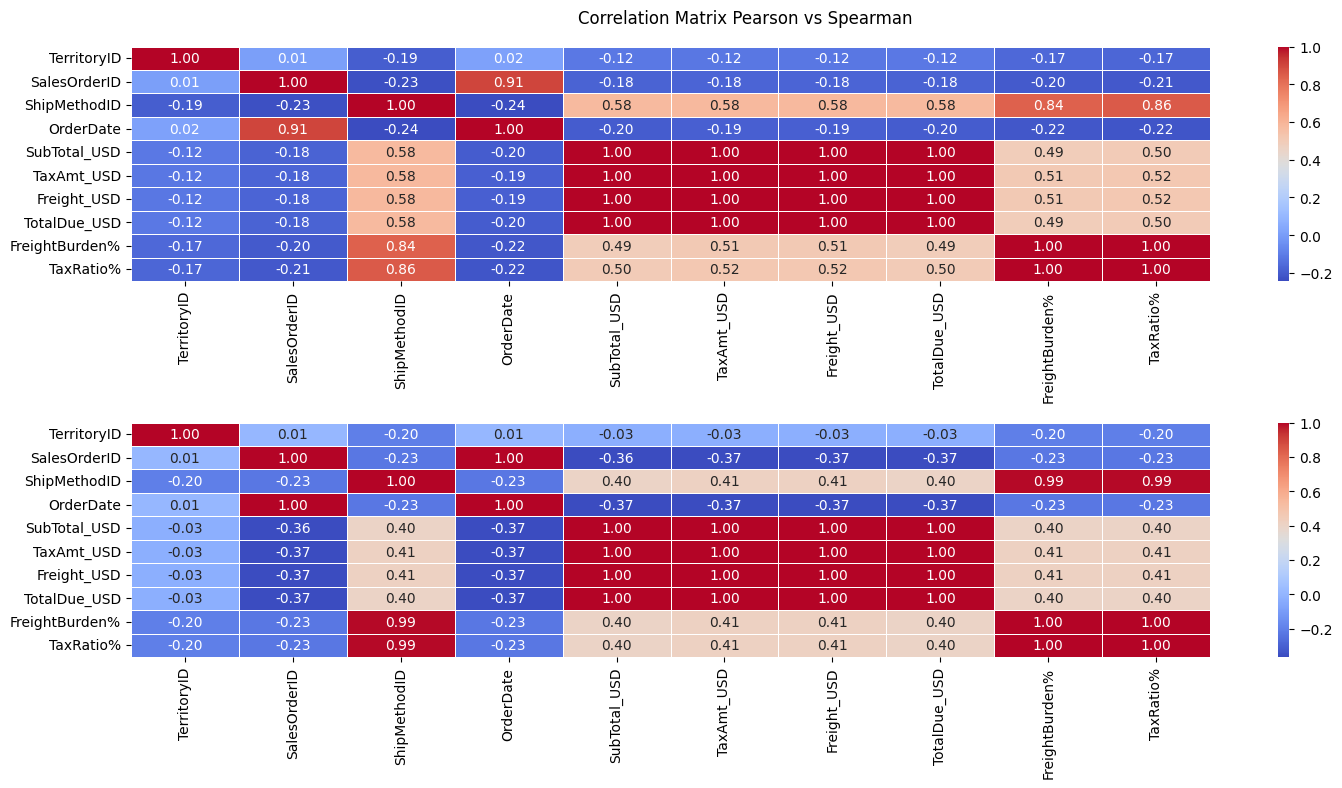

In [36]:
import seaborn as sns

temp_table = currency_header_df.drop(columns=['EndOfDayRate', 'FromCurrencyCode', 'ToCurrencyCode', 'CustomerID',
                                            'SubTotal', 'TaxAmt', 'Freight', 'CurrencyRateID', 'SubTotalCategorized']) # doesn't add much weight to the correlation strength / transactions in foreign currency

# pearson coefficient correlation matrix
corr_matrix_pearson = temp_table.corr(method='pearson')

# spearman coefficient correlation matrix
corr_matrix_spearman = temp_table.corr(method='spearman')

fig, ax = plt.subplots(2, 1, figsize=(15, 8))

sns.heatmap(corr_matrix_pearson,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.4,
            ax=ax[0])

sns.heatmap(corr_matrix_spearman,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidth=0.4,
            ax=ax[1])

plt.suptitle('Correlation Matrix Pearson vs Spearman')

plt.tight_layout()
plt.show()

In [37]:
from scipy import stats

# seperating ShipMethod's FreightBurden% into two groups for a statistical test
group_1_freight = currency_header_df[refined_df_orderheader['ShipMethodID'] == 1]['FreightBurden%']
group_5_freight = currency_header_df[refined_df_orderheader['ShipMethodID'] == 5]['FreightBurden%']

group_1_tax = currency_header_df[refined_df_orderheader['ShipMethodID'] == 1]['TaxRatio%']
group_5_tax = currency_header_df[refined_df_orderheader['ShipMethodID'] == 5]['TaxRatio%']

# using a non-parametric two-sample and two-tails test as an alternative to t-test without assumption data distribution
stat_freight, p_value_freight = stats.mannwhitneyu(group_1_freight, group_5_freight, alternative='two-sided')
if p_value_freight < 0.05:
    print('Significant difference, Shipment 1 and 5 have different freight burden')
else:
    print('No significant difference between the two shipment types')

# using the same approach but to validate the weight of TaxRatio% groups difference significance
stat_tax, p_value_tax = stats.mannwhitneyu(group_1_tax, group_5_tax, alternative='two-sided')
if p_value_tax < 0.05:
    print('Significant difference, Shipment 1 and 5 have different tax ratios')
else:
    print('No significant difference between the two shipment types')

Significant difference, Shipment 1 and 5 have different freight burden
Significant difference, Shipment 1 and 5 have different tax ratios


In [38]:
features = ['SubTotal', 'TaxAmt', 'Freight', 'TotalDue']
cov_matrix_4d = refined_df_orderheader[features].cov().values

# Compute eigenvalues
eigenvalues, _ = np.linalg.eig(cov_matrix_4d)

# Sort eigenvalues from largest to smallest
eigenvalues = sorted(eigenvalues, reverse=True) # eigenvalues represent the total explain variance for each component (where each component is a set of feature coefficients and data points)

for i, val in enumerate(eigenvalues):
    component_ratio = (val / sum(eigenvalues))
    print(f'Component{i}, ExplainedVariance: {component_ratio*100:.3f}%')

Component0, ExplainedVariance: 99.998%
Component1, ExplainedVariance: 0.002%
Component2, ExplainedVariance: 0.000%
Component3, ExplainedVariance: -0.000%


- previously we calculated `TaxRatio%` of `TotalDue` without `FreightBurden%`, yet it appears they perfectly correlate in this visualization, and the reason behind such is both calculations relied on `SubTotal` as baseline to reach the cost ratio to TotalDue, even the original features confirm such with a perfect 1.00 correlation, they are suggesting multicollinearity existance, thus why using them only to explain `ShipMetodID` is a better approach
- `SubTotal`, `TaxAmt`, `Freight` and `TotalDue` suffer from multicollinearity between each other, suggesting that their variations moves in perfect synchrony (the rate of change between features is in almost perfect harmony)
> look at the output of `eigenvalues` components ratio, indeed it means our features covariance synchronize by 99.998% of the time, explaining why we see a perfect 1.00 correlation between the 4 features
- look at `ShipMethodID` groups significance with `TaxRatio%` and `FreightBurden%` we conclude that different shipmentmethods impact `FreightBurden%` and `TaxRatio%` directly, using the non-parametric two-sample and two-tailed test such as **Mann-Whitney U test** to spot any significance between the two groups, since **ShipMethodID** follows a nominal numerical data structure, it is appropriate here to use this test, then use pearson or spearman coefficient matrix

In [39]:
refined_ship_method = df_shipment.drop(columns=['rowguid', 'ModifiedDate'])
overhead_subset = currency_header_df[['ShipMethodID', 'TaxRatio%', 'FreightBurden%']]

refined_ship_method

,ShipMethodID,Name,ShipBase,ShipRate
0,1,XRQ - TRUCK GROUND,3.95,0.99
1,2,ZY - EXPRESS,9.95,1.99
2,3,OVERSEAS - DELUXE,29.95,2.99
3,4,OVERNIGHT J-FAST,21.95,1.29
4,5,CARGO TRANSPORT 5,8.99,1.49


In [40]:
shipment_category_subset = pd.merge(refined_ship_method, overhead_subset, on='ShipMethodID')

shipment_category_subset.head(5)

,ShipMethodID,Name,ShipBase,ShipRate,TaxRatio%,FreightBurden%
0,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
1,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
2,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
3,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44
4,1,XRQ - TRUCK GROUND,3.95,0.99,7.41,2.44


In [41]:
# ShipRate represent act as a booking fee to intialize product intention of placement in the transporting medium
# ShipBase represent is the product measure factor multiplier like weight, length or volume or all combined

shipment_cols = ['ShipBase', 'ShipRate', 'TaxRatio%', 'FreightBurden%']

# switch between 1 (Ground trucks) and 5 (transport cargo) inside the loop the see different outputs whom support the generated insight below 
for i in shipment_cols:
    unique_output = shipment_category_subset[shipment_category_subset['ShipMethodID'] == 1][i].unique()
    print(f'{i}, unique_values: {unique_output}')

ShipBase, unique_values: [3.95]
ShipRate, unique_values: [0.99]
TaxRatio%, unique_values: [7.41]
FreightBurden%, unique_values: [2.44]


> Data profiling reveals that for Ground Trucks (ShipMethodID: 1), all four shipment attributes operate on a strict flat-rate system, showing zero independent variance across the dataset. However, when switching to international Cargo Transport (ShipMethodID: 5), these fields unlock dynamic behavior—specifically, FreightBurden% and TaxRate% vary independently, beautifully capturing the shifting tax structures of different foreign markets.

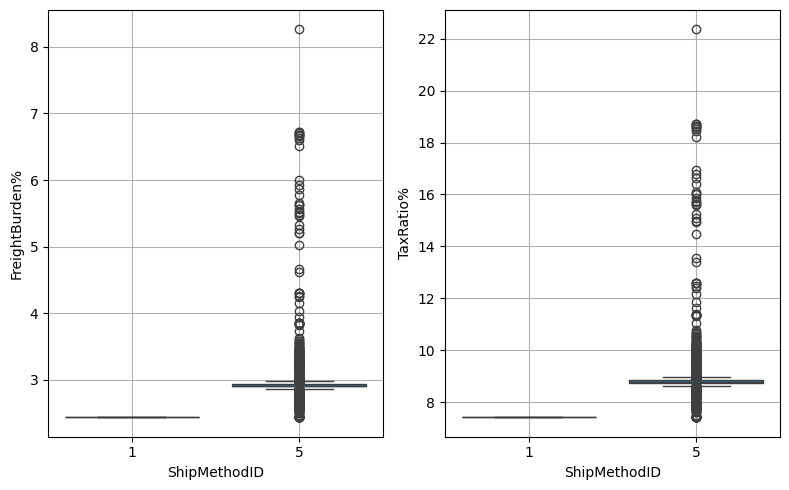

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(8, 5))

sns.boxplot(x='ShipMethodID',
            y='FreightBurden%',
            data=currency_header_df,
            ax=ax[0])

sns.boxplot(x='ShipMethodID',
            y='TaxRatio%',
            data=currency_header_df,
            ax=ax[1])

plt.tight_layout()
ax[0].grid(True)
ax[1].grid(True)

plt.show()

In [43]:
# relying heavily on two transport mediums, grounds trucks taking the lead in both markets, with the remaining portion reserved for transport cargo
currency_header_df['ShipMethodID'].unique()

array([5, 1])

In [44]:
domestic_transport_share = currency_header_df[
    (currency_header_df['TerritoryID'].isin([1, 2, 3, 4, 5])) &
    (currency_header_df['CurrencyRateID'] == 13520)]['ShipMethodID'].value_counts()

foreign_transport_share = currency_header_df[
    (~currency_header_df['TerritoryID'].isin([1, 2, 3, 4, 5])) &
    (currency_header_df['CurrencyRateID'] != 13520)]['ShipMethodID'].value_counts()

# 79.42% of domestic transport relies on Transport ground trucks of type XQR | the remaining 20.58% of transport mediums is reserved for Transport Cargos 5
domestic_transport_ratio = np.round((domestic_transport_share.loc[1] / (domestic_transport_share.loc[1] + domestic_transport_share.loc[5]))*100, 2)

# interesting, 91.57% of foreign markets transport mediums relies on ground trucks of type XQR | 8.43% is reserved for Transport Cargos 5
foreign_transport_ratio = np.round((foreign_transport_share.loc[1] / (foreign_transport_share.loc[1] + foreign_transport_share.loc[5]))*100, 2)

In [45]:
# total transport mediums between domestic and foreign markets
domestic_T = (domestic_transport_share.loc[1] + domestic_transport_share.loc[5])
foreign_T = (foreign_transport_share.loc[1] + foreign_transport_share.loc[5])

# 46.28% of business logistics arsenal operates within the domestic market, whereby 53.72% operates in foreign markets
domestic_T_share = np.round((domestic_T / (foreign_T + domestic_T))*100, 2)

- **Group 1 is a fixed-rate rule**: relies on Ground truncks for products transport Serves as the primary operational backbone (79.42% of domestic transport relies on Transport ground trucks, whereby 91.57% of foreign markets transport relies on the same medium). It features absolute zero variance for both the domestic and foreign markets, operating under a rigid, corporate flat-rate pricing matrix designed to streamline high-volume domestic movements.
- **Group 2 is a dynamic-rate rule**: Handles irregular, heavy-duty, domestic or cross-border cargo (20.58% of transport mediums is reserved for Transport Cargos 5, and surprisingly 8.43% of foreign markets transport medium is reserved for transport cargo). This method exhibits a severe right-hand skew and extreme upward outliers (up to 22%), absorbing the volatile expenses of international tariffs, transport distances, domestic and foreign market infrastructure

- but I noticed that we only relied on two mediums `ShipMethodID(1 and 5)` representing ground trucks and transport cargos, yet the remaining mediums such as **'ZY - EXPRESS'**, **'OVERSEAS - DELUXE'**, **'OVERNIGHT J-FAST'** appear to be reserved for `PurchaseOrderHeader` table, indicating that these mediums yet also **Transport carge, and Ground Trucks** are reserved for when the business buys components and not selling for customers or standard B2B clients

### preparing `refined_df_product`, `refined_df_product_category` and `df_orderdetails` table for cross-analysis with `product_track`

In [46]:
refined_df_product_category = df_product_category.drop(columns=['rowguid', 'ModifiedDate'])

In [47]:
refined_df_product = df_product.drop(columns=['ModifiedDate', 'rowguid'])
refined_df_product.head(1)

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,Weight,DaysToManufacture,ProductLine,Class,Style,ProductSubcategoryID,ProductModelID,SellStartDate,SellEndDate,DiscontinuedDate
0,1,Adjustable Race,AR-5381,0,0,NaN,1000,750,0.0,0.0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,2008-04-30,NaT,None


In [48]:
empty_cols = []
consistant_ratio_cols = []

for col, null_ratio in zip(refined_df_product.columns, refined_df_product.isna().mean()):
    if null_ratio == 0:
        continue

    null_ratio_normalized = null_ratio*100
        
    if 42 <= null_ratio_normalized <= 43:
        consistant_ratio_cols.append((col, f'null_ratio: {null_ratio_normalized:.2f}'))

    elif null_ratio_normalized < 100:
        print(f'{col}, null_ratio: {null_ratio_normalized:.2f}%')

    else:
        empty_cols.append((col, null_ratio_normalized))

Color, null_ratio: 49.21%
Size, null_ratio: 58.13%
SizeUnitMeasureCode, null_ratio: 65.08%
WeightUnitMeasureCode, null_ratio: 59.33%
Weight, null_ratio: 59.33%
ProductLine, null_ratio: 44.84%
Class, null_ratio: 50.99%
Style, null_ratio: 58.13%
ProductSubcategoryID, null_ratio: 41.47%
ProductModelID, null_ratio: 41.47%
SellEndDate, null_ratio: 80.56%


In [49]:
empty_cols

[('DiscontinuedDate', 100.0)]

> 100% empty records in `DiscontinuedDate` would suggest that all deployed products are still active and does align with the business model expectations
- `SizeUnitMeasureCode` represents the product's measurement type, with Gemini support (A Large Language Model serving as the best peer auditor and collaborator to this process), we concluded that the products are sold without regarding the measurement factor to calculate different costs, which interestingly means we would safely eliminate this factor from our freightburden hypothesis task
    - if we dig deeper into `StandardCost` and `ListPrice` we see placeholders following this format: **0.000** for `StandardCost` and **0.00** for `ListPrice`, our best current conclusion is within these 504 products, 200 of which are non finished products with placeholders (0), the business defined these products as raw components rather than standalone products representing ~=40% of the business product arsenal, 2% reserved to non finished products yet being standalone Assembly, leaving ~58% for finished products
- `Weight` and `WeightUnitMeasureCode` null_ratio ~=60% indicates that ~=40% of the products are being evaluated with the weight factor in mind, yet the weight factor doesn't respect the state of the product neither finished or not, but rather represent a rather more interesting layer indicating the existance of the weight factor is tied to non-raw component products regardless of their finished status

In [50]:
placeholder_count = refined_df_product[
    (refined_df_product['StandardCost'] == 0) &
    (refined_df_product['FinishedGoodsFlag'] == '0')].shape[0]

placeholder_ratio = f'placeholder_ratio: {(placeholder_count / refined_df_product.shape[0])*100:.2f}%'
placeholder_ratio

'placeholder_ratio: 39.68%'

In [51]:
safety_lock_check = f'active_product_safety_check: {refined_df_product['SafetyStockLevel'].notna().mean()*100:.2f}%'
ReorderPoint = f'ReorderPoint_ratio: {refined_df_product['ReorderPoint'].notna().mean()*100:.2f}%'

FinishedProductCount = refined_df_product['FinishedGoodsFlag'].value_counts()

Finished_product_ratio = FinishedProductCount.iloc[0] / (refined_df_product.shape[0])
placeholder_p_ratio = placeholder_count / refined_df_product.shape[0]

print(f'finished_product_ratio: {(Finished_product_ratio)*100:.2f}%\nplaceholders_ratio: {placeholder_p_ratio*100:.2f}%\n{safety_lock_check}\n{ReorderPoint}')

finished_product_ratio: 58.53%
placeholders_ratio: 39.68%
active_product_safety_check: 100.00%
ReorderPoint_ratio: 100.00%


In [52]:
resale_products = refined_df_product['MakeFlag'].value_counts()

resale_products_ratio = np.round((resale_products.iloc[1] / (resale_products.iloc[0] + resale_products.iloc[1]))*100, 2)
resale_products_ratio

np.float64(47.42)

In [53]:
''' according to the documentation for adventureworks database,
MakeFlag=1 indicate that products manufactored internally whereby MakeFlag=0 indicates
that it is a resale product'''

resale_products

MakeFlag
0    265
1    239
Name: count, dtype: int64

- 47.42% of the products are manufactured internally, but the remaining 52.58% are resale products

In [54]:
internal_m_subset = refined_df_product[['MakeFlag', 'DaysToManufacture']]

manufacture_internal_summary = internal_m_subset[
    (internal_m_subset['MakeFlag'] == '1')]

manufacture_resale_summary = internal_m_subset[
    (internal_m_subset['MakeFlag'] == '0')]

manufacture_internal_summary['DaysToManufacture'].unique()

array([1, 2, 4])

In [55]:
manufacture_resale_summary['DaysToManufacture'].unique()

array([0, 1])

- interesting, internal product manufactoring takes between 1-2 to 4 days, whereby resale products takes a short period between 0-1 days which logical since processing overhead is minimized due to the absense of raw components purchasing, preprocessing, etc.... in comparison to internal manufacturing

In [56]:
manufacture_internal_summary['DaysToManufacture'].unique()

array([1, 2, 4])

In [57]:
refined_df_product.head(1)

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,Weight,DaysToManufacture,ProductLine,Class,Style,ProductSubcategoryID,ProductModelID,SellStartDate,SellEndDate,DiscontinuedDate
0,1,Adjustable Race,AR-5381,0,0,NaN,1000,750,0.0,0.0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,2008-04-30,NaT,None


In [58]:
reorder_point = refined_df_product[['SafetyStockLevel', 'ReorderPoint']].copy().dropna()
reorder_point['ReorderPointRatio%'] = np.round((reorder_point['ReorderPoint'] / (reorder_point['SafetyStockLevel']))*100, 2)

reorder_point['ReorderPointRatio%'].unique()

array([75.])

- it seems the business model has set up a flat and consistent threshold of 75% resupply point, whereby on the logistics side the threshold criteria is fulfilled respectively for the domestic market

In [59]:
refined_df_product['Productstatus'] = (pd.to_datetime(refined_df_product['SellEndDate']) - pd.to_datetime(refined_df_product['SellStartDate'])).dt.days
refined_df_product.rename(columns={'Name': 'ProductName'}, inplace=True)

product_subset = refined_df_product.drop(columns=['Color', 'Size', 'WeightUnitMeasureCode', 'Weight',
                                                'MakeFlag', 'ProductNumber', 'Weight', 'DaysToManufacture',
                                                'ProductLine', 'Class', 'Style', 'FinishedGoodsFlag',
                                                'WeightUnitMeasureCode', 'ProductModelID', 'DiscontinuedDate', 'SizeUnitMeasureCode',
                                                'ReorderPoint', 'SafetyStockLevel', 'SellEndDate', 'SellStartDate']).copy() # won't contribute to FM-to-ProductID patterns mapping

In [60]:
# B2B customers represent 6.47% of our customers for different transactions
df_customers['BusinessEntities'] = df_customers['StoreID'].notna()

business_count = df_customers[df_customers['StoreID'].notna()].shape[0]
customer_count = df_customers[df_customers['StoreID'].isna()].shape[0]

refined_customers_df = df_customers.drop(columns=['AccountNumber', 'rowguid', 'ModifiedDate',
                                                'StoreID', 'PersonID']).copy()

business_ratio = np.round((business_count / (customer_count + business_count))*100, 2)
business_ratio

np.float64(6.74)

- **6.74%** of our customers are businesses, whereby **93.26%** of customers are individual buyers! (based on current transactions report, not a permanent state of customers)

In [61]:
salesorderheader = currency_header_df[['CustomerID','SalesOrderID', 'SubTotal_USD', 'TerritoryID',
                                        'ShipMethodID', 'OrderDate']].copy()

salesorderdetails = df_orderdetails[['SalesOrderID', 'ProductID', 'LineTotal', 'OrderQty', 'SpecialOfferID' ,'UnitPriceDiscount']].copy()

territoryID = df_salesterritory.drop(columns=['rowguid', 'ModifiedDate', 'CostLastYear', 'CostYTD']).copy() # CostLastYear, CostYTD values are equal to 0
df_sales_specialoffer['DiscountDuration'] = df_sales_specialoffer['EndDate'] - df_sales_specialoffer['StartDate']

# renaming to avoid conflict with TerritoryID
refined_ship_method.rename(columns={'Name': 'Medium_name'}, inplace=True)
territoryID.rename(columns={'Name': 'TerritoryName'}, inplace=True)

refined_special_offer = df_sales_specialoffer.drop(columns=['rowguid', 'ModifiedDate', 'MaxQty', 'StartDate', 'EndDate', 'MinQty']).copy()

sales_layer = salesorderdetails.copy()

customer_header_subset = pd.merge(sales_layer,  currency_header_df[['CustomerID', 'ShipMethodID', 'CurrencyRateID', 'SalesOrderID',
                                                                    'EndOfDayRate', 'FromCurrencyCode','ToCurrencyCode', 'OrderDate']],
                                                                    on='SalesOrderID')

customer_territory_layer = pd.merge(refined_customers_df, territoryID, on='TerritoryID')
sales_territory_layer = pd.merge(customer_territory_layer, customer_header_subset, on='CustomerID')
special_offer_layer = pd.merge(sales_territory_layer, refined_special_offer, on='SpecialOfferID')
product_layer = pd.merge(product_subset, special_offer_layer, on='ProductID')

summary_table = pd.merge(product_layer, refined_ship_method, on='ShipMethodID')

summary_table['LineTotal_USD'] = summary_table['LineTotal'] / summary_table['EndOfDayRate']

summary_table.shape


(121317, 34)

In [62]:
summary_table['LineTotal_USD'].sum()

np.float64(102587093.21138135)

- very well, it seems the Business's invoice system operate on `ProductID` basis and not on `OrderQty`, meaning that no matter the quantity of the same product you place within that same product, it would be a single invoice, whereby if you place single orders on different products it would flag each order as different invoices for the same customer

In [63]:
foreign_logistics = summary_table[(summary_table['TerritoryID'].isin([6, 7, 8, 9, 10]))]['ShipMethodID'].value_counts()
domestic_logistics = summary_table[(summary_table['TerritoryID'].isin([1, 2, 3, 4, 5]))]['ShipMethodID'].value_counts()

domestic_ground_truck_share = domestic_logistics.loc[1] / (domestic_logistics.loc[1] + foreign_logistics.loc[1])
foreign_ground_truck_share = foreign_logistics.loc[1] / (domestic_logistics.loc[1] + foreign_logistics.loc[1])

domestic_cargo_share = domestic_logistics.loc[5] / (domestic_logistics.loc[5] + foreign_logistics.loc[5])
foreign_cargo_share = foreign_logistics.loc[5] / (foreign_logistics.loc[5] + domestic_logistics.loc[5])

print(f'_____Domestic transport_____: \ndomestic ground share: {domestic_ground_truck_share*100:.2f}%\ndomestic cargo share {domestic_cargo_share*100:.2f}%\n')
print(f'_____Foreign transport_____: \nforeign ground share: {foreign_ground_truck_share*100:.2f}%\nforeign cargo share: {foreign_cargo_share*100:.2f}%')

_____Domestic transport_____: 
domestic ground share: 35.34%
domestic cargo share 63.71%

_____Foreign transport_____: 
foreign ground share: 64.66%
foreign cargo share: 36.29%


- different markets transport mediums share

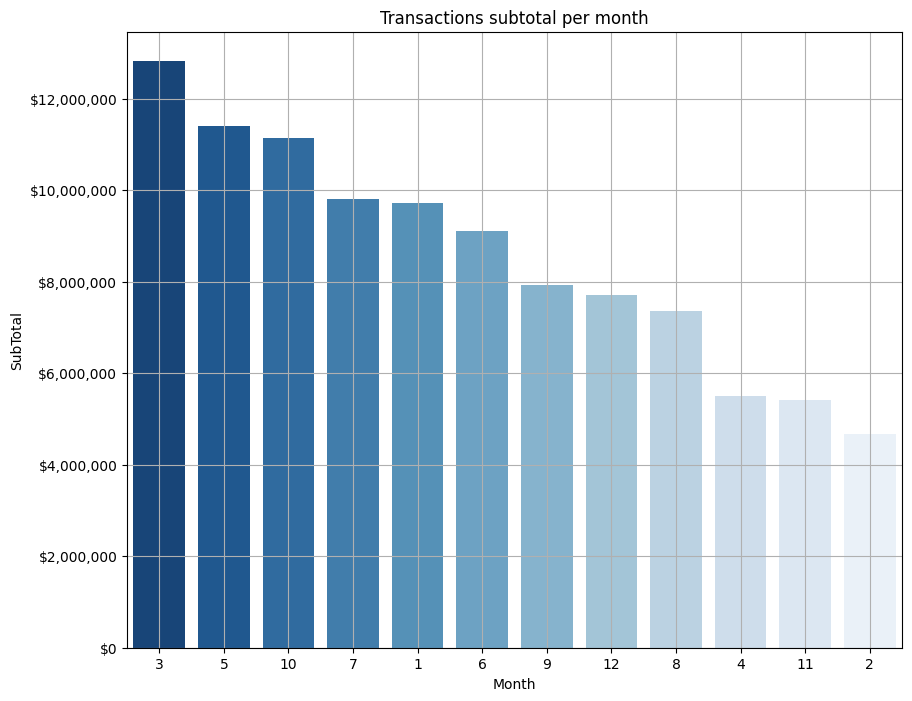

In [64]:
summary_table['OrderDate'] = summary_table['OrderDate'].dt.month
x_m = summary_table['OrderDate']

monthly_sum = summary_table.groupby(x_m)[['LineTotal_USD']].sum().sort_values(by='LineTotal_USD', ascending=False)

plt.figure(figsize=(10, 8))

sns.barplot(data=monthly_sum,
            x='OrderDate', 
            y='LineTotal_USD',
            palette="Blues_r",
            order=monthly_sum.index)

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))

plt.ylabel('SubTotal')
plt.xlabel('Month')

plt.title('Transactions subtotal per month')

plt.grid(True)
plt.show()


- very well, it seems **March**, **May** and **October** are our top transactions months respectively order as per highlighted in the visualization <- what drives specifically these months sales increase

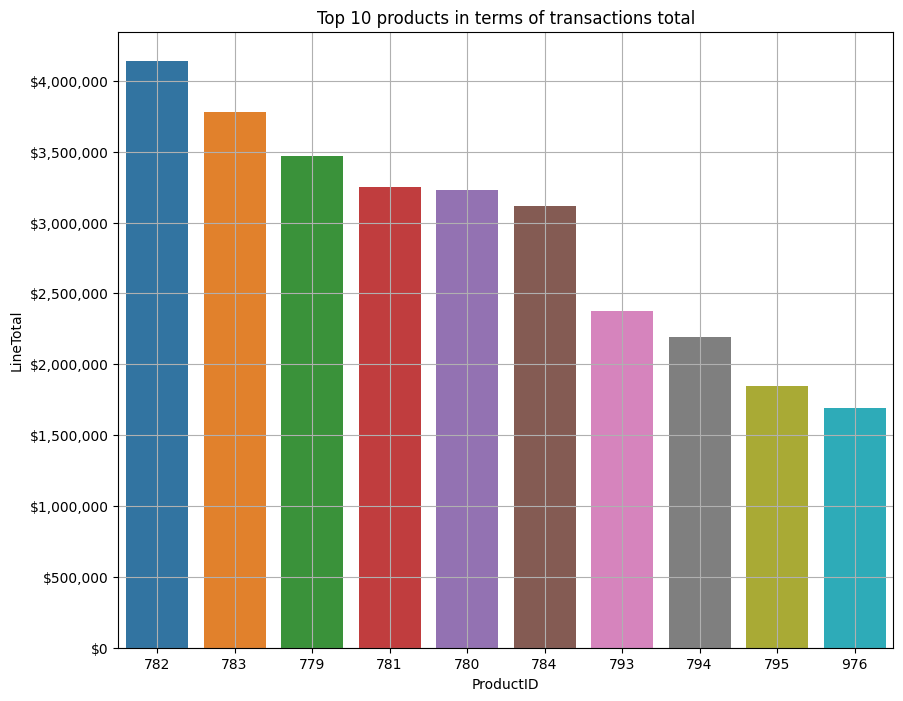

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

summary_table['ProductID'] = summary_table['ProductID'].astype('str')

val = summary_table.groupby('ProductID')['LineTotal_USD'].sum().sort_values(ascending=False).iloc[0:10]
data = summary_table.groupby('ProductID')[['LineTotal_USD']].sum().sort_values(ascending=False, by='LineTotal_USD').iloc[0:10]

x_ = val.index
y_ = val.values

plt.figure(figsize=(10, 8))

sns.barplot(data=data,
            x=x_,
            y=y_,
            hue='ProductID')

plt.ylabel('LineTotal')
plt.xlabel('ProductID')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.title('Top 10 products in terms of transactions total')

plt.grid(True)
plt.show()

In [66]:
df_product_subcategory.drop(columns=['rowguid', 'ModifiedDate'], inplace=True)

In [67]:
temp_product_name = summary_table[['ProductID', 'ProductName', 'ProductSubcategoryID']].copy()

top_products = pd.merge(val.reset_index(name='Total_spent'), temp_product_name, on='ProductID')
top_products_subcategory = pd.merge(top_products, df_product_subcategory, on='ProductSubcategoryID')

top_10_purchased_products = top_products_subcategory['ProductID'].unique()
top_products_category_T = top_products_subcategory.groupby('ProductID')['ProductName'].unique()

for p, c in zip(top_10_purchased_products, top_products_category_T.str[0]):
    print(f'{p}: {c}')

782: Mountain-200 Silver, 38
783: Mountain-200 Silver, 42
779: Mountain-200 Silver, 46
781: Mountain-200 Black, 38
780: Mountain-200 Black, 42
784: Mountain-200 Black, 46
793: Road-250 Black, 44
794: Road-250 Black, 48
795: Road-250 Black, 52
976: Road-350-W Yellow, 48


In [68]:
list(top_products_subcategory['Name'].unique())

['Mountain Bikes', 'Road Bikes']

- top 10 best selling products `(Total spending)`, ranked `Highest -> Lowest`:
    - **Mountain-200 Silver, 38 (cm)**
    - **Mountain-200 Silver, 42 (cm)**
    - **Mountain-200 Silver, 46 (cm)**
    - **Mountain-200 Black, 38 (cm)**
    - **Mountain-200 Black, 42 (cm)**
    - **Mountain-200 Black, 46 (cm)**
    - **Road-250 Black, 44 (cm)**
    - **Road-250 Black, 48 (cm)**
    - **Road-250 Black, 52 (cm)**
    - **Road-350-W Yellow, 48 (cm)**

- top best selling product's subcategories `(Total spending)`, ranked `Highest -> Lowest`: 
    - **Mountain Bikes**
    - **Road Bikes**

In [69]:
subcategory_subset = summary_table[['ProductSubcategoryID']]
sub_category_name = pd.merge(subcategory_subset, df_product_subcategory, on='ProductSubcategoryID')
category_name = pd.merge(sub_category_name, df_product_category, on='ProductCategoryID')

category_name.rename(columns={'Name_x': 'Subcategory_name', 'Name_y': 'Category_name' }, inplace=True)

category_name['Subcategory_name'].value_counts().reset_index().head(5)


,Subcategory_name,count
0,Road Bikes,20944
1,Tires and Tubes,17495
2,Mountain Bikes,12457
3,Helmets,9180
4,Bottles and Cages,8425


- top 5 most frequent product purchase subcategories `(Purchasing frequency)`:
    - Road Bikes
    - Tires and Tubes
    - Mountain Bikes
    - Helmets
    - Bottles and Cages

In [70]:
monthly_product_share_T = summary_table[['ProductID', 'LineTotal_USD', 'OrderDate']]

top_10_products = ['782', '783', '779', '781', '780', '784', '793', '794', '795', '976']

product_monthly_share_T = monthly_product_share_T[
    monthly_product_share_T['ProductID'].isin(top_10_products)
]

product_monthly_share_T.head(5)

,ProductID,LineTotal_USD,OrderDate
33284,779,1193.349108,6
33285,779,1209.840426,6
33286,779,2319.990000,6
33287,779,1209.840426,6
33288,779,2319.990000,6


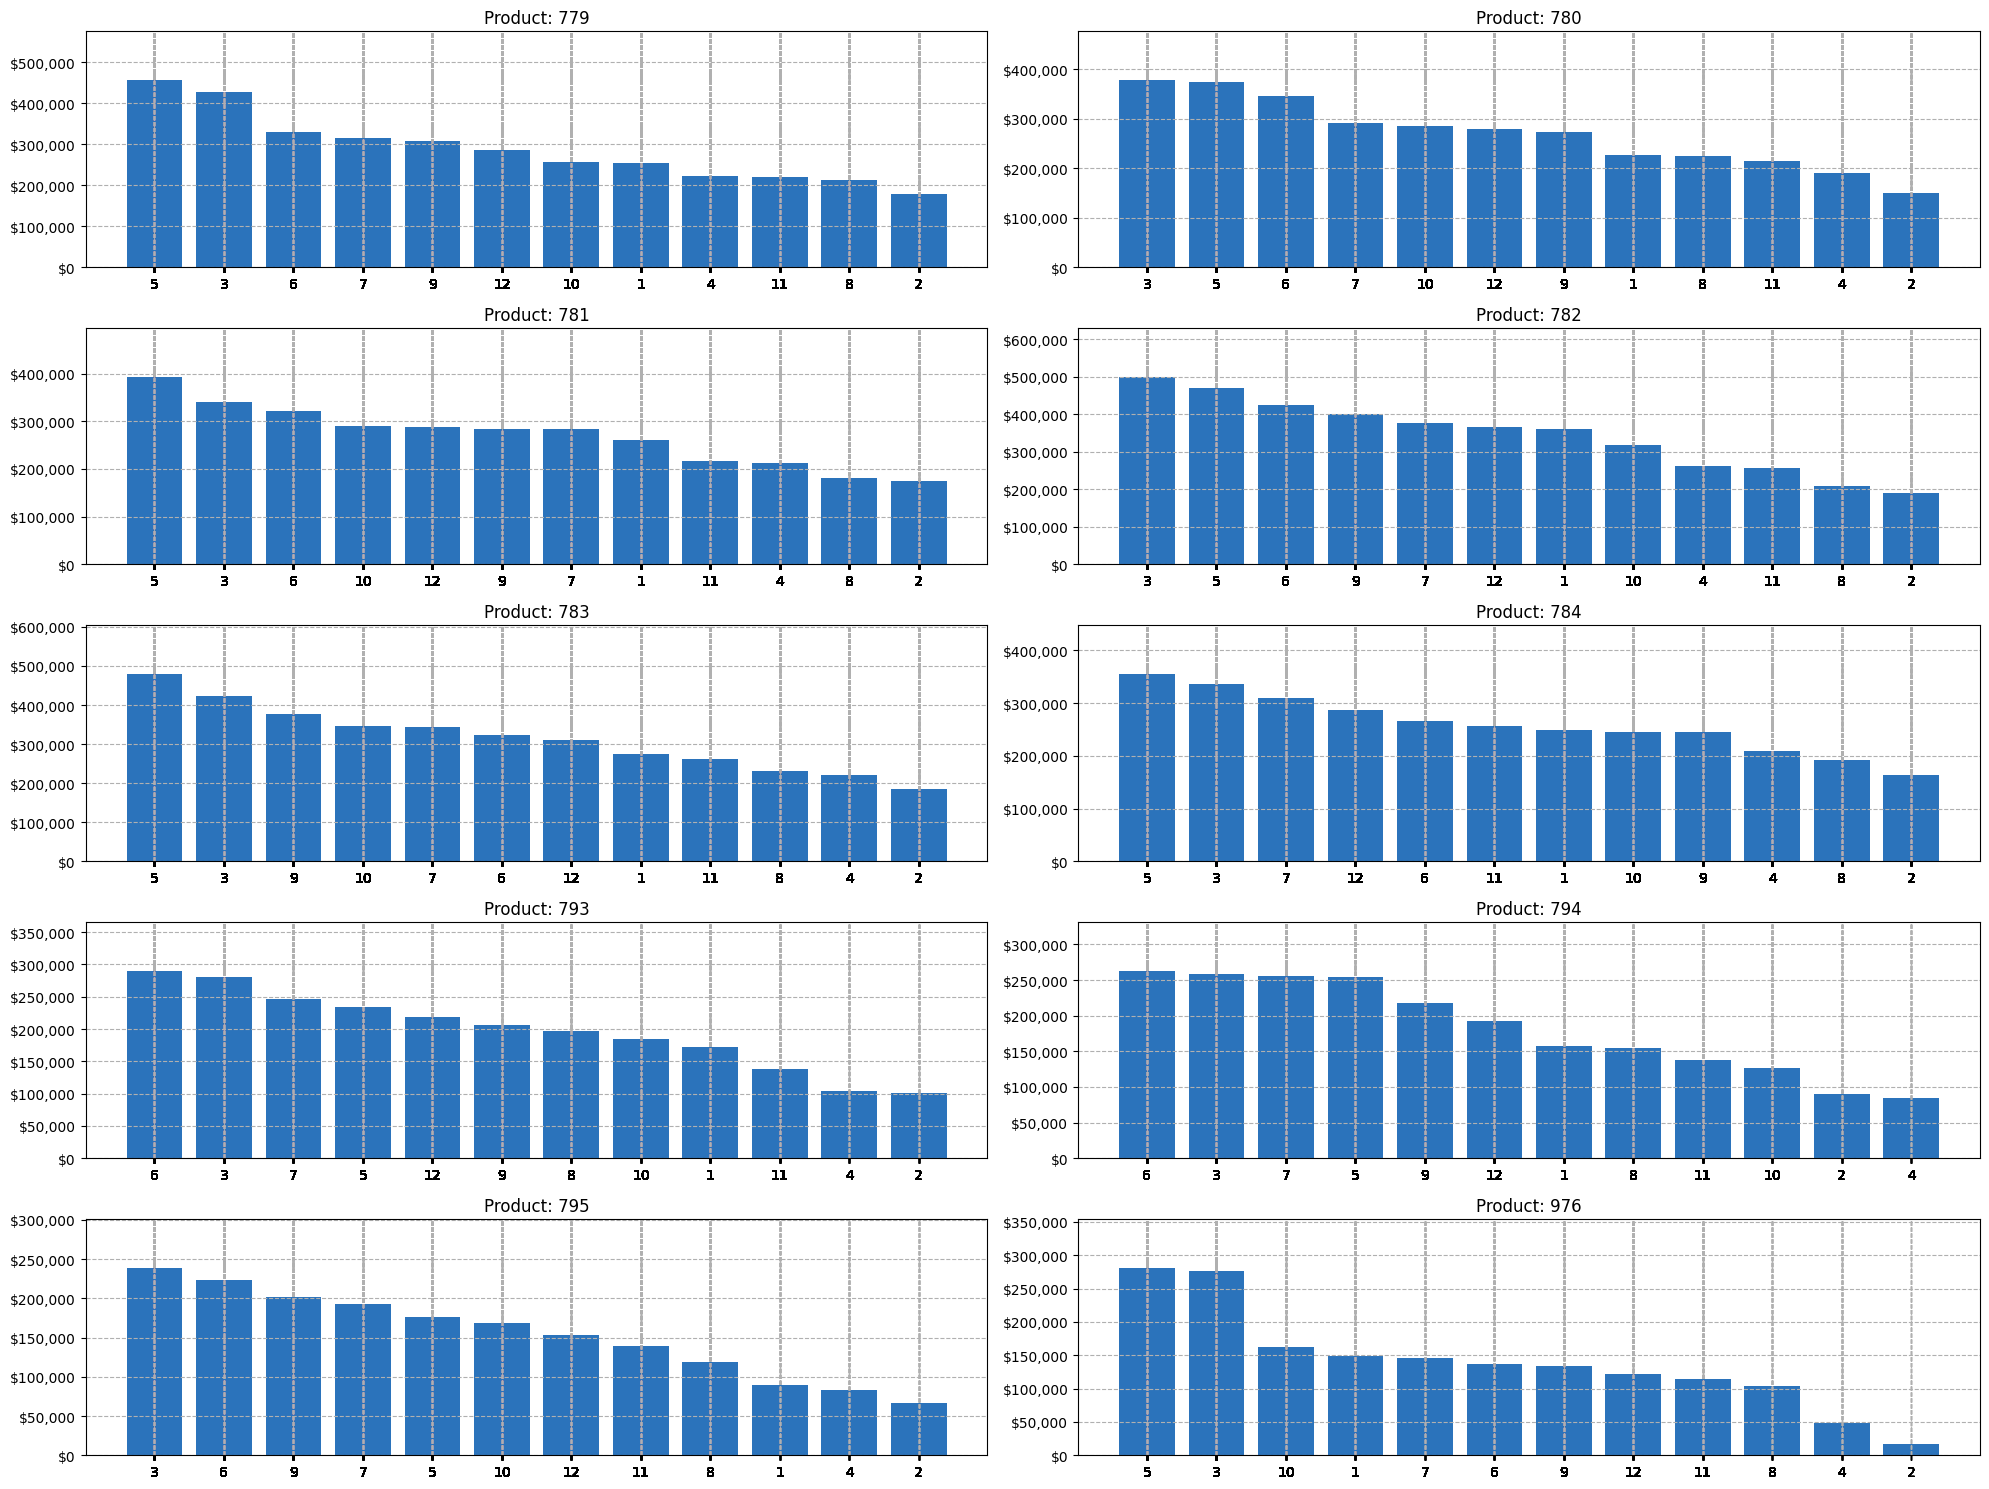

In [71]:
productID_p = product_monthly_share_T['ProductID']

fig, axes = plt.subplots(5, 2, figsize=(20, 15))

axes = axes.flatten()

# looping throught productIDs
for i, product_id in enumerate(productID_p.unique()):
    ax = axes[i] # using the index to track each subplot

    # filtering each subplot by each unique productID
    product_data = product_monthly_share_T[
        product_monthly_share_T['ProductID'] == product_id]
    
    # changing data type for categorized descending plotting
    product_data['OrderDate'] = product_data['OrderDate'].astype(str)
    
    product_data_sorted = product_data.groupby('OrderDate')['LineTotal_USD'].sum().sort_values(ascending=False).reset_index()

    # plotting barplots for each plot object based on each unique product
    ax.bar(product_data_sorted['OrderDate'],
           product_data_sorted['LineTotal_USD'],
            color="#2b73bb")
    
    # normalizing transactions into financial notation
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
    
    # adding more xticks to highlight each month product transactions total
    ax.set_xticks(product_data['OrderDate'])
    ax.grid(True, linestyle='--')
    ax.set_title(f'Product: {product_id}')

    # increase y-axis top limit
    current_ymin, current_ymax = ax.get_ylim()
    ax.set_ylim(0, current_ymax * 1.20)

plt.tight_layout()
plt.show()

## top 10 products monthly share summary:

#### the same rule applies here for different colors and Bikes, demand peak late-spring to summer season as it highlights that the golden rule for Bike demands cluster within that timeline, we notices an outlier of demand in september which we could say that it is driven by back-to-school demand and fitness activities drivers, lowest selling months are mostly driven by seasonal demand shifts, April and February are the most frequent months mentioned under lowest selling months reflecting uncertainty in unexpected weather changes mostly driven by rain
- **Product 779: Mountain-200 Silver, 46 (cm)**
    - High Selling Months: May, Mar, Jun
    - Lowest Selling Months: Nov, Aug, Feb
- **Product 782: Mountain-200 Silver, 38 (cm)**
    - High Selling Months: Mar, May, Jun
    - Lowest Selling Months: Nov, Aug, Feb
- **Product 780: Mountain-200 Black, 42 (cm)**
    - High Selling Months: Mar, May, Jun
    - Lowest Selling Months:Nov, Apr, Feb
- **Product 781: Mountain-200 Black, 38 (cm)**
    - High Selling Months: May, Mar, Jun
    - Lowest Selling Months: Apr, Aug, Feb
- **Product 783: Mountain-200 Silver, 42 (cm)**
    - High Selling Months: May, Mar, Sep
    - Lowest Selling Months: Aug, Apr, Feb
- **Product 784: Mountain-200 Black, 46 (cm)**
    - High Selling Months: May, Mar, Jul
    - Lowest Selling Months: Apr, Aug, Feb
- **Product 793: Road-250 Black, 44 (cm)**
    - High Selling Months: Jun, Mar, Jul
    - Lowest Selling Months: Nov, Apr, Feb
- **Product 794: Road-250 Black, 48 (cm)**
    - High Selling Months: Jun, Mar, July
    - Lowest Selling Months: Oct, Feb, Apr
- **Product 795: Road-250 Black, 52 (cm)**
    - High Selling Months: Mar, Jun, Sep
    - Lowest Selling Months: Jan, Apr, Feb
- **Product 976: Road-350-W Yellow, 48 (cm)**
    - High Selling Months: May, Mar
    - Lowest Selling Months: Aug, Apr, Feb

In [72]:
temp_table = summary_table[['ProductID', 'CustomerID', 'LineTotal_USD']]
customer_business = pd.merge(temp_table, refined_customers_df, on='CustomerID', how='outer')

customer_business[customer_business['LineTotal_USD'].isna()]['BusinessEntities'].value_counts()

BusinessEntities
True    701
Name: count, dtype: int64

In [73]:
Inactive_c_count = refined_customers_df['CustomerID'].unique().shape[0] - summary_table['CustomerID'].unique().shape[0]
print(f'Inactive customers count: {Inactive_c_count}')
print(f'Inactive customers ratio: {Inactive_c_count / (summary_table['CustomerID'].unique().shape[0] + Inactive_c_count)*100:.2f}%')

Inactive customers count: 701
Inactive customers ratio: 3.54%


- 701 of customers are Inactive representing 3.54% of customers base, all by which never placed an order or grew interest in products catalog

In [74]:
Business_customer_summary = customer_business[customer_business['LineTotal_USD'].notna()]['BusinessEntities'].value_counts()

print(f"Business transactions's share: {Business_customer_summary.iloc[0] / (Business_customer_summary.iloc[0] + Business_customer_summary.iloc[1])*100:.2f}%")
print(f"Individual transactions's share: {Business_customer_summary.iloc[1] / (Business_customer_summary.iloc[0] + Business_customer_summary.iloc[1])*100:.2f}%")

Business transactions's share: 50.21%
Individual transactions's share: 49.79%


#### what an impressive twist here, although Businesses represents only ~7% of customer base they account for 50% of transactions share (frequency) yet also represent 74.60% of all transactions total (spending)

In [75]:
Business_T_total = customer_business[(customer_business['BusinessEntities'] == True) & (customer_business['LineTotal_USD'])]['LineTotal_USD'].sum()
Customer_T_total = customer_business[customer_business['BusinessEntities'] == False]['LineTotal_USD'].sum()

print(f'Business customers transactions total: ${Business_T_total:,.0f}\nIndividual customers transactions total: ${Customer_T_total:,.0f}')
print(f'\nBusiness Transactions total share ratio: {(Business_T_total / (Business_T_total + Customer_T_total))*100:.2f}%')

Business customers transactions total: $76,531,943
Individual customers transactions total: $26,055,151

Business Transactions total share ratio: 74.60%


- very interesting indeed, while Business being only 7% of customer base and accounting for more than 50% of transactions share, they hold a 74.60% of transactions total revenue for AdventureWorks Business

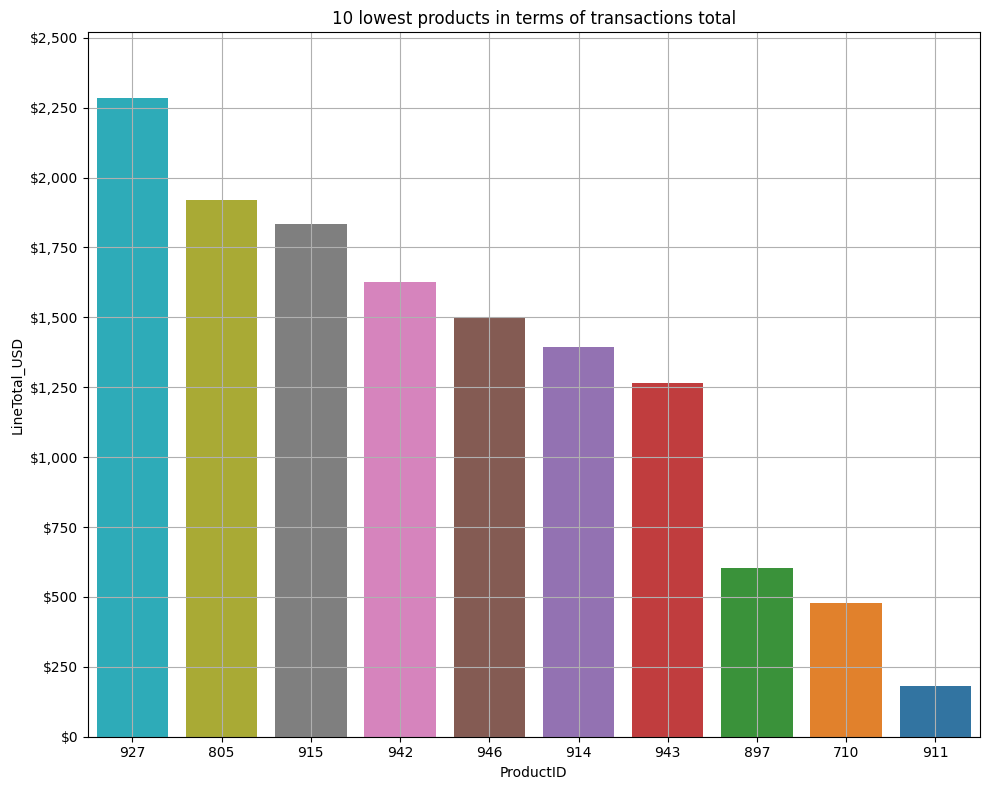

In [76]:
lowest_products = (summary_table.groupby('ProductID')[['LineTotal_USD']]
    .sum()
    .sort_values(ascending=True, by='LineTotal_USD')
    .reset_index()
    .head(10))

plt.figure(figsize=(10, 8))

x_lowest = lowest_products['ProductID']
y_lowest = lowest_products['LineTotal_USD']

sns.barplot(data=lowest_products,
            x=x_lowest,
            y=y_lowest,
            hue='ProductID',
            order=lowest_products['ProductID'].sort_index(ascending=False))

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'${y:,.0f}'))

ylim_min, ylim_max = plt.ylim()
plt.ylim(0, ylim_max * 1.05)

plt.title('10 lowest products in terms of transactions total')

plt.yticks(np.arange(0, ylim_max*1.05, 250))

plt.grid(True)
plt.tight_layout()
plt.show()

In [77]:
temp_product_name_L = summary_table[['ProductID', 'ProductName', 'ProductSubcategoryID']].copy()

lowest_products_L = pd.merge(lowest_products, temp_product_name_L, on='ProductID')
lowest_products_category = pd.merge(lowest_products_L, df_product_subcategory, on='ProductSubcategoryID')

lowest_10_purchased_products = lowest_products_category['ProductID'].sort_index(ascending=False).unique()
lowest_products_category_L = lowest_products_category.groupby('ProductID')['ProductName'].unique()

for p, c in zip(lowest_10_purchased_products, lowest_products_category_L.str[0]):
    print(f'{p}: {c}')

927: Mountain Bike Socks, L
805: LL Headset
915: LL Touring Frame - Blue, 58
942: LL Road Seat/Saddle
946: LL Touring Seat/Saddle
914: ML Touring Seat/Saddle
943: LL Mountain Frame - Black, 52
897: ML Mountain Frame-W - Silver, 38
710: LL Mountain Frame - Black, 40
911: LL Touring Handlebars


In [78]:
list(lowest_products_category['Name'].sort_values(ascending=False).unique())

['Touring Frames',
 'Socks',
 'Saddles',
 'Mountain Frames',
 'Headsets',
 'Handlebars']

- 10 lowest sold products, `(Total spending)` ranked `Highest -> Lowest`:
    - **927: Mountain Bike Socks, L**
    - **805: Bike Headset, LL**
    - **915: Touring Frame - Blue, LL-58**
    - **942: Bike Road Seat/Saddle, LL**
    - **946: Touring Seat/Saddle, LL**
    - **914: Touring Seat/Saddle, ML**
    - **943: Mountain Frame - Black, LL-52**
    - **897: Mountain Frame-W - Silver, ML-38**
    - **710: Mountain Frame - Black, LL-40**
    - **911: touring Handlebars, LL**

- lowest products's subcategories `(Total spending)`, ranked `Highest -> Lowest`: 
    - Touring Frames
    - Socks
    - Saddles
    - Montain Frames
    - Headsets
    - Handlebars

In [79]:
subcategory_subset = summary_table[['ProductSubcategoryID']]
sub_category_name = pd.merge(subcategory_subset, df_product_subcategory, on='ProductSubcategoryID')
category_name = pd.merge(sub_category_name, df_product_category, on='ProductCategoryID')

category_name.rename(columns={'Name_x': 'Subcategory_name', 'Name_y': 'Category_name' }, inplace=True)

least_frequent_subcategories = category_name['Subcategory_name'].value_counts().sort_values(ascending=True).reset_index().head(5)

least_frequent_subcategories.sort_values(by='count', ascending=False)

,Subcategory_name,count
4,Headsets,266
3,Locks,260
2,Chains,250
1,Bike Stands,249
0,Forks,200


- top 5 least frequent product purchase subcategories `(Purchasing frequency)`:
    - Headsets
    - Locks
    - Chains
    - Bike Stands
    - Forks (Bike Forks)

In [80]:
monthly_product_share_L = summary_table[['ProductID', 'LineTotal_USD', 'OrderDate']]

lowest_10_products = ['927', '805', '915', '942', '946', '914', '943', '897', '710', '911']

product_monthly_share_L = monthly_product_share_L[
    monthly_product_share_L['ProductID'].isin(lowest_10_products)
]

product_monthly_share_L.head(3)

,ProductID,LineTotal_USD,OrderDate
6278,710,17.1,10
6279,710,17.1,3
6280,710,5.7,10


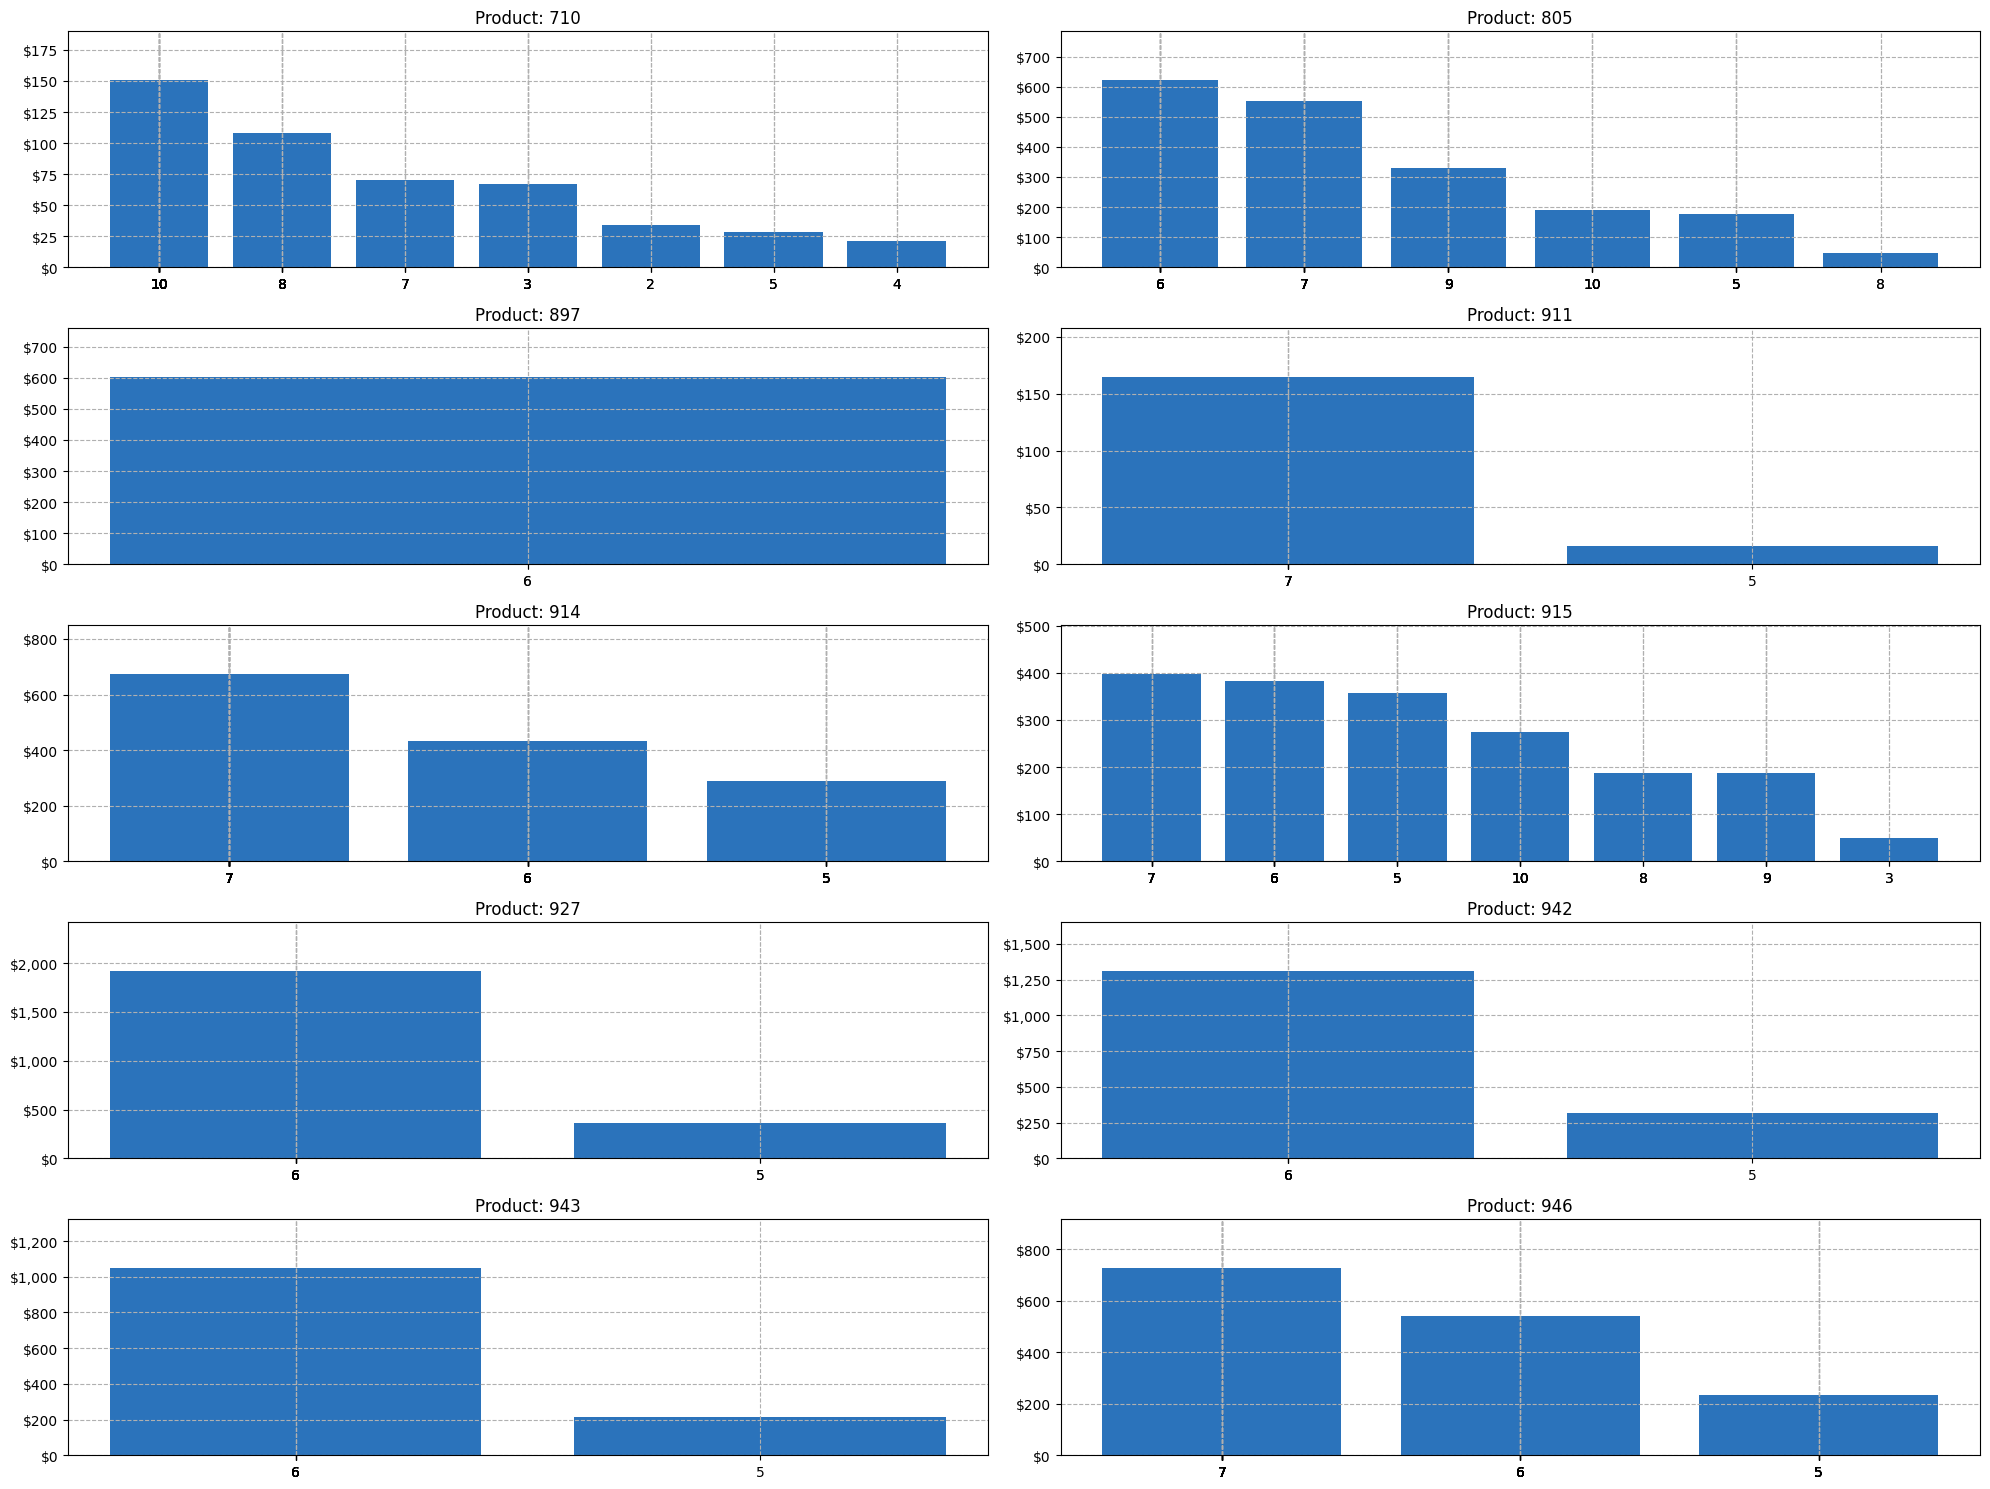

In [81]:
productID_p = product_monthly_share_L['ProductID']

fig, axes = plt.subplots(5, 2, figsize=(20, 15))

axes = axes.flatten()

# looping throught productIDs
for i, product_id in enumerate(productID_p.unique()):
    ax = axes[i] # using the index to track each subplot

    # filtering each subplot by each unique productID
    product_data = product_monthly_share_L[
        product_monthly_share_L['ProductID'] == product_id]
    
    # changing data type for categorized descending plotting
    product_data['OrderDate'] = product_data['OrderDate'].astype(str)
    
    product_data_sorted = product_data.groupby('OrderDate')['LineTotal_USD'].sum().sort_values(ascending=False).reset_index()

    # plotting barplots for each plot object based on each unique product
    ax.bar(product_data_sorted['OrderDate'],
           product_data_sorted['LineTotal_USD'],
            color="#2b73bb")
    
    # normalizing transactions into financial notation
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
    
    # adding more xticks to highlight each month product transactions total
    ax.set_xticks(product_data['OrderDate'])
    ax.grid(True, linestyle='--')
    ax.set_title(f'Product: {product_id}')

    # increase y-axis top limit
    current_ymin, current_ymax = ax.get_ylim()
    ax.set_ylim(0, current_ymax * 1.20)

plt.tight_layout()
plt.show()

## lowest 10 products monthly share

#### Interesting, Bike demand for individual components, Frames, etc... peak in summer season, matching the pattern of fully assembled bikes reflecting a unified demand surge throughtout the summer season, yet despite the unified demand surge, and in terms of Transactions total spending it appears that customers rather prefer standalone and completed bikes over individual Bike parts
- **Product 927: Mountain Bike Socks, L**
    - High Selling Months: Jun
    - Lowest Selling Months:May
- **Product 805: Bike Headset, LL**
    - High Selling Months: Jun, Jul, Sep
    - Lowest Selling Months: Oct, May, Aug
- **Product 915: Bike Touring Frame - Blue, LL-58**
    - High Selling Months: Jul, Jun, May
    - Lowest Selling Months: Aug, Sep, Mar
- **Product 942: Bike Road Seat/Saddle, LL**
    - High Selling Months: Jun
    - Lowest Selling Months: May
- **Product 946: Bike Touring Seat/Saddle, LL**
    - High Selling Months: Jul, Jun
    - Lowest Selling Months: May
- **Product 914: Bike Touring Seat/Saddle, ML**
    - High Selling Months: Jul, Jun
    - Lowest Selling Months: May
- **Product 943: Mountain Bike Frame - Black, LL-52**
    - High Selling Months: Jun
    - Lowest Selling Months: May
- **Product 897: Mountain Bike Frame-W - Silver, ML-38**
    - High Selling Months: Jun
    - Lowest Selling Months: `NULL`
- **710: Mountain Bike Frame - Black, LL-40**
    - High Selling Months: Oct, Aug
    - Lowest Selling Months: Feb, May, Apr
- **Product 911: Bike Touring Handlebars, LL**
    - High Selling Months: Jul
    - Lowest Selling Months: May

In [82]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

transactions_subset = top_transactions_total.drop('CustomerID', axis=1).copy()

X = add_constant(transactions_subset)
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [vif(X.values, i) for i in range(X.shape[1])]
vif_data

,Feature,VIF
0,const,2.478742
1,Transactions_total,1.294812
2,Transactions_count,1.294812


- we utilize VIF and add_constant to detect multicollinearity existence as we aimed to switch covariance mode from 'full' to 'diag' to reduce computational tax

In [83]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

''' natural logarithmic transforming to normalize whales (outliers) within a normal range and distribution.
Do NOT run this cell more than once, as the logarithmic transformation will repeat and introduce biaseded outputs'''
transactions_subset['Transactions_total'] = np.log1p(transactions_subset['Transactions_total'])
transactions_subset['Transactions_count'] = np.log1p(transactions_subset['Transactions_count'])

X_features = transactions_subset[['Transactions_total', 'Transactions_count']].copy()
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_features)

bic_scores = []
k_range = range(1, 21)

for i in k_range: # going further doesn't add much decrease as we more beyond 10 clusters range
    gmm = GaussianMixture(n_components=i,
                covariance_type='diag',
                init_params='kmeans',
                n_init=10,
                reg_covar=1e-6, # hyperparmeter in GMM which act as a the minimum variance threshold between features within clusters
                random_state=42)
    
    gmm.fit(X_scaled)
    bic_scores.append([(i), (gmm.bic(X_scaled))])

sorted(bic_scores, key=lambda x: x[1])


[[20, -158028.1826960526],
 [19, -157605.6819187346],
 [18, -157204.29912602488],
 [17, -156849.64761258918],
 [16, -156615.50997591403],
 [13, -155065.33630026702],
 [15, -154773.78673199753],
 [14, -154404.98095358524],
 [11, -154380.06609448453],
 [12, -154227.27560198883],
 [10, -149725.63846196746],
 [9, -148976.38443679296],
 [8, -147470.5671373341],
 [7, -143083.32156378002],
 [6, -137249.66121339117],
 [4, -130798.9204190719],
 [5, -120638.28881479992],
 [3, -117949.11288473986],
 [2, -46401.80713873443],
 [1, 108554.1770169156]]

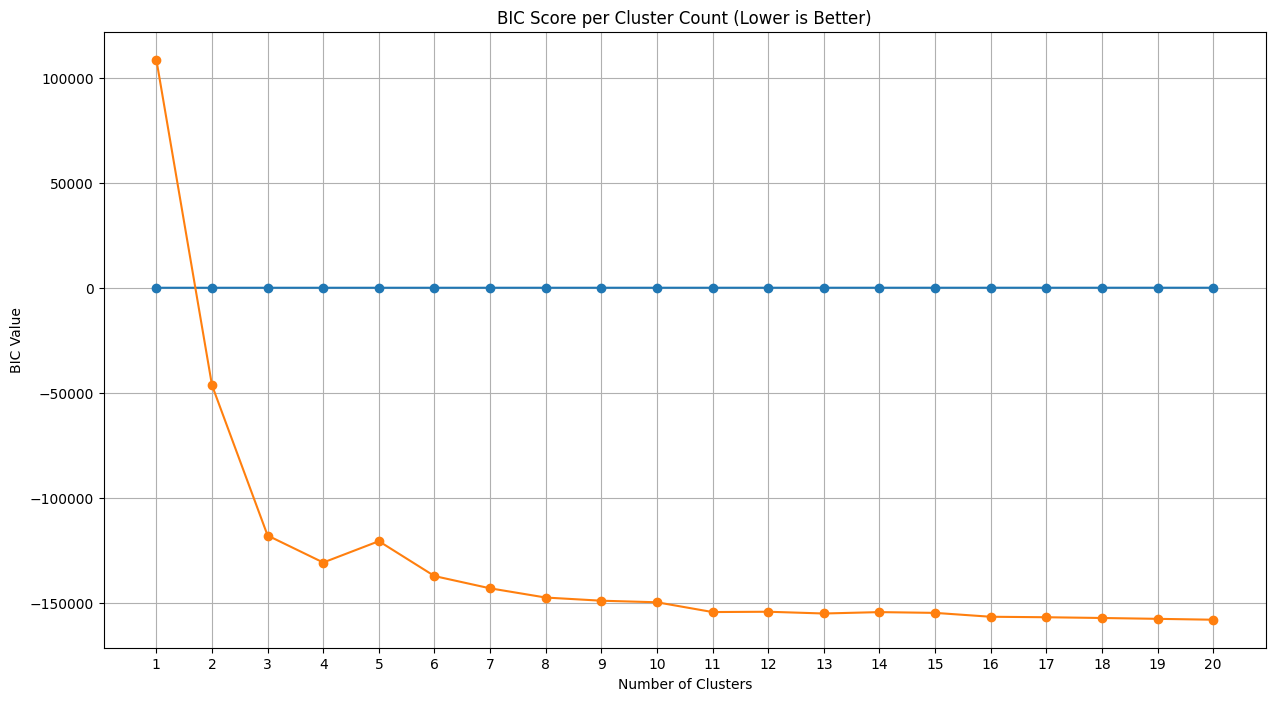

In [84]:
plt.figure(figsize=(15, 8))

plt.plot(k_range, bic_scores, marker='o')
plt.title('BIC Score per Cluster Count (Lower is Better)')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Value')

plt.xticks(k_range)

plt.grid(True)
plt.show()

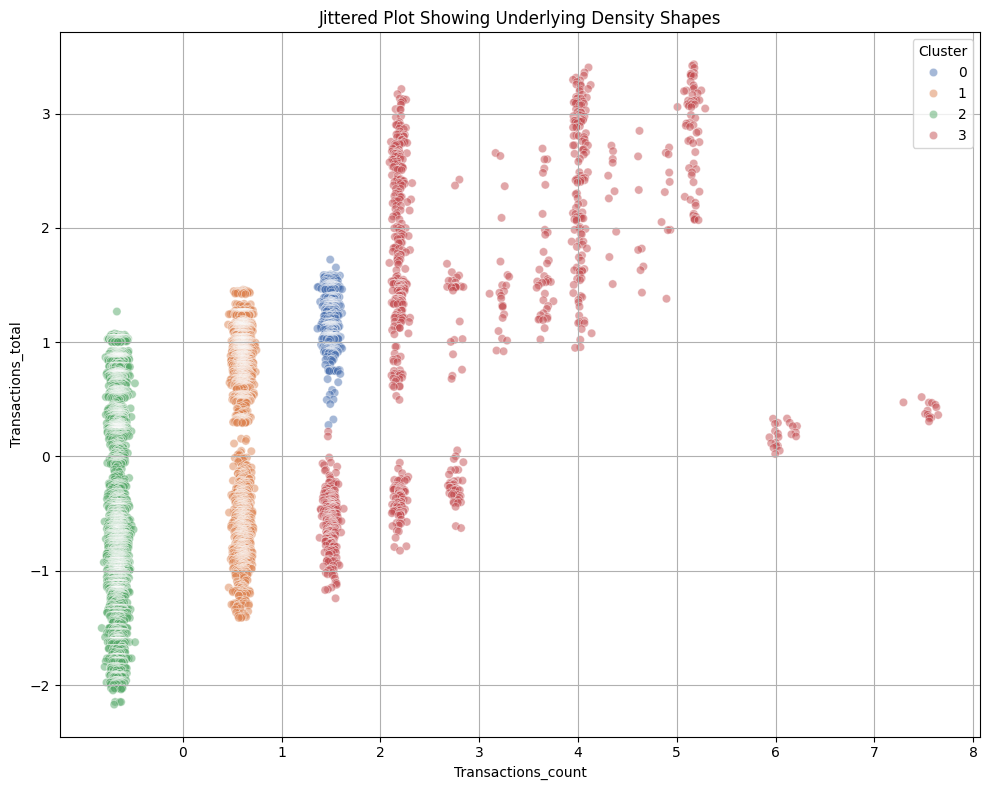

In [85]:
gmm_finalized = GaussianMixture(n_components=4,
                                covariance_type='diag',
                                init_params='kmeans',
                                reg_covar=1e-6,
                                n_init=10,
                                random_state=42)

transactions_subset['Cluster'] = gmm_finalized.fit_predict(X_scaled)

jittered_count = X_scaled[:, 1] + np.random.normal(0, 0.04, size=len(transactions_subset))

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=jittered_count, 
    y=X_scaled[:, 0], 
    hue=transactions_subset['Cluster'],
    palette='deep',
    alpha=0.5
)
plt.title("Jittered Plot Showing Underlying Density Shapes")

plt.xlabel('Transactions_count')
plt.ylabel('Transactions_total')

plt.xticks(np.arange(0, 9, 1))

plt.grid(True)
plt.tight_layout()
plt.show()

### althought the statistical elbow method highlight the k=4 to be the optimal choice for GMM, but k=8 tells a much more precise story by which is directly actionable for differentiated campaign design, discount tiering, and retention prioritization."

In [86]:
# restart the notebook environment or comment these two lines before rerunning the cell
transactions_subset['Transactions_total'] = np.expm1(transactions_subset['Transactions_total'])
transactions_subset['Transactions_count'] = np.expm1(transactions_subset['Transactions_count'])

transactions_summary = transactions_subset.groupby('Cluster').agg(
    customer_count_cluster=('Cluster', 'count'),
    Frequency_mean=('Transactions_count', 'mean'),
    Total_mean=('Transactions_total', 'mean'),
    Total_spent=('Transactions_total', 'sum')
)

transactions_summary['customer_cluster_ratio'] = (
    (transactions_summary['customer_count_cluster'] / transactions_summary['customer_count_cluster'].sum()*100)
    .round(2)
    .astype(str) + '%')

transactions_summary['Total_spent'] = (
    (transactions_summary['Total_spent'])
    .map(lambda x: f"${x:,.2f}")  
)

transactions_summary['Total_mean'] = (
    (transactions_summary['Total_mean'])
    .map(lambda x: f"${x:,.2f}")  
)

transactions_summary

,customer_count_cluster,Frequency_mean,Total_mean,Total_spent,customer_cluster_ratio
Cluster,,,,,
0,910,3.000000,"$5,894.39","$5,363,891.67",4.76%
1,5473,2.000000,"$2,443.47","$13,373,124.98",28.63%
2,11649,1.000000,$574.08,"$6,687,485.76",60.93%
3,1087,5.648574,"$70,986.74","$77,162,590.81",5.69%


In [87]:
# a clustering algorithm which train on mixed data types in a dataset (e.g, int and categorical)
from kmodes.kprototypes import KPrototypes

scaler_c = StandardScaler()

behavior_subset = summary_table[['CustomerID', 'LineTotal_USD', 'ProductSubcategoryID']].copy()
features_x = behavior_subset[['LineTotal_USD', 'ProductSubcategoryID']].copy()

# scaling linetotal in this part is necessary, for the ProductSubcategoryID feature the scaling operate on a dynamic one-hot encoding with gamma scaler based on linetotal variance formula
features_x['LineTotal_USD'] = np.log1p(features_x['LineTotal_USD'])
X_scaled_c = scaler_c.fit_transform(features_x[['LineTotal_USD']])

features_x['LineTotal_scaled'] = X_scaled_c

# isolating the subset to point into a new memory address instead of being a guardrail for features_x, (.copy(deep=True))
finalized_subset = features_x[['LineTotal_scaled', 'ProductSubcategoryID']].copy(deep=True)

# Total Mixed dissimilarity
Total_cost = []
n_range = range(1, 7)

'''for i in n_range:
    k_proto = KPrototypes(n_clusters=i,
                          init='Cao',
                          random_state=42,
                          n_jobs=-1)
    
    k_proto.fit(finalized_subset, categorical=[1])
    Total_cost.append([(i), (k_proto.cost_)])


sorted(Total_cost, key=lambda x: x[0])'''

"for i in n_range:\n    k_proto = KPrototypes(n_clusters=i,\n                          init='Cao',\n                          random_state=42,\n                          n_jobs=-1)\n\n    k_proto.fit(finalized_subset, categorical=[1])\n    Total_cost.append([(i), (k_proto.cost_)])\n\n\nsorted(Total_cost, key=lambda x: x[0])"

In [88]:
X_constant = add_constant(finalized_subset)
vif_datas = pd.DataFrame()

vif_datas['Feature'] = X_constant.columns
vif_datas['VIF'] = [vif(X_constant.values, i) for i in range(X_constant.shape[1])]
vif_datas

,Feature,VIF
0,const,7.514181
1,LineTotal_scaled,3.761658
2,ProductSubcategoryID,3.761658


In [89]:
'''plt.figure(figsize=(15, 8))

plt.plot(n_range, Total_cost, marker='o')
plt.title('Total cost Score per Cluster Count (Lower is Better)')
plt.xlabel('Number of Clusters')
plt.ylabel('Total cost value Value')

plt.xticks(n_range)

plt.grid(True)
plt.show()'''

"plt.figure(figsize=(15, 8))\n\nplt.plot(n_range, Total_cost, marker='o')\nplt.title('Total cost Score per Cluster Count (Lower is Better)')\nplt.xlabel('Number of Clusters')\nplt.ylabel('Total cost value Value')\n\nplt.xticks(n_range)\n\nplt.grid(True)\nplt.show()"

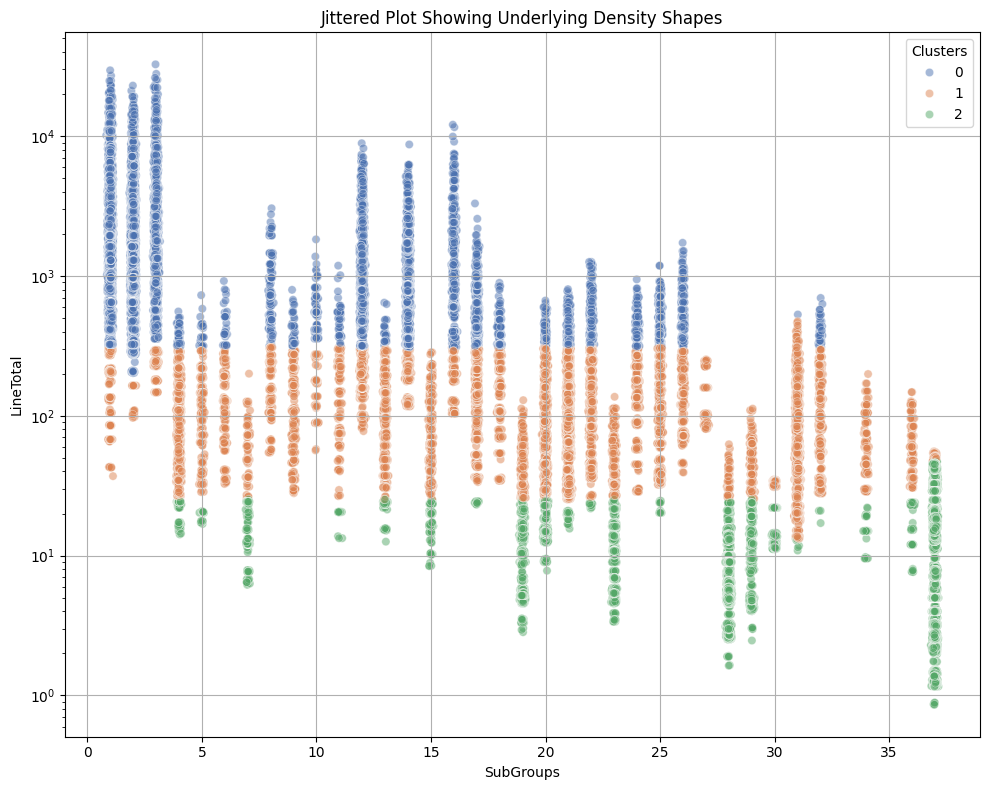

In [90]:
k_proto = KPrototypes(n_clusters=3,
                          init='Cao',
                          random_state=42,
                          n_jobs=-1)

finalized_subset['Clusters'] = k_proto.fit_predict(finalized_subset, categorical=[1])
finalized_subset['LineTotal_unscaled'] = np.expm1(features_x['LineTotal_USD'])

# defining random static seed for reusability
np.random.seed(42)
jittered_count_ = finalized_subset['ProductSubcategoryID'] + np.random.normal(0, 0.04, size=len(finalized_subset['ProductSubcategoryID']))

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=jittered_count_, 
    y=finalized_subset['LineTotal_unscaled'],
    hue=finalized_subset['Clusters'],
    palette='deep',
    alpha=0.5
)
plt.title("Jittered Plot Showing Underlying Density Shapes")

plt.xlabel('SubGroups')
plt.ylabel('LineTotal')

plt.yscale('log')

plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
subcategory_summary = finalized_subset.groupby(['ProductSubcategoryID', 'Clusters']).agg(
    transaction_count=('LineTotal_unscaled', 'count'),
    total_revenue=('LineTotal_unscaled', 'sum'),
    average_spending=('LineTotal_unscaled', 'mean')
).round(2)

# orders ProductSubcategoryID in an ascending order and allows for customized condition checks
subcategory_summary = subcategory_summary.reset_index()

finalized_subcategory = pd.merge(subcategory_summary,
                                df_product_subcategory,
                                on='ProductSubcategoryID',
                                how='left')

finalized_subcategory.head(3)

,ProductSubcategoryID,Clusters,transaction_count,total_revenue,average_spending,ProductCategoryID,Name
0,1.0,0,12109,34238135.68,2827.49,1,Mountain Bikes
1,1.0,1,348,68987.24,198.24,1,Mountain Bikes
2,2.0,0,20924,40577899.72,1939.30,1,Road Bikes


In [92]:
cluster_0_subcategory_share = finalized_subcategory[finalized_subcategory['Clusters'] == 0].groupby('ProductSubcategoryID')['total_revenue'].sum().reset_index()
cluster_0_subcategory_share['Subcategory_share'] = ((cluster_0_subcategory_share['total_revenue'] / cluster_0_subcategory_share['total_revenue'].sum())*100).round(3)

subcat_names = finalized_subcategory[['ProductSubcategoryID', 'Name']].drop_duplicates().copy()
cluster_0_subcategory_share = cluster_0_subcategory_share.merge(subcat_names,
                                                                on='ProductSubcategoryID',
                                                                how='left')

cluster_0_subcategory_share.sort_values(by='total_revenue', ascending=False, inplace=True)

cluster_0_subcategory_share['total_revenue'] = (
    (cluster_0_subcategory_share['total_revenue'])
    .map(lambda x: f'${x:,}')
)

cluster_0_subcategory_share['Subcategory_share'] = (
    (cluster_0_subcategory_share['Subcategory_share'])
    .astype(str) + '%'
)

cluster_0_subcategory_share.head(5)

,ProductSubcategoryID,total_revenue,Subcategory_share,Name
1,2.0,"$40,577,899.72",41.073%,Road Bikes
0,1.0,"$34,238,135.68",34.656%,Mountain Bikes
2,3.0,"$13,249,595.05",13.411%,Touring Bikes
10,12.0,"$4,311,274.86",4.364%,Mountain Frames
12,14.0,"$3,419,446.7",3.461%,Road Frames


- 1th cluster summary

In [93]:
cluster_1_subcategory_share = finalized_subcategory[finalized_subcategory['Clusters'] == 1].groupby('ProductSubcategoryID')['total_revenue'].sum().reset_index()
cluster_1_subcategory_share['Subcategory_share'] = ((cluster_1_subcategory_share['total_revenue'] / cluster_1_subcategory_share['total_revenue'].sum())*100).round(3)

subcat_names = finalized_subcategory[['ProductSubcategoryID', 'Name']].drop_duplicates().copy()
cluster_1_subcategory_share = cluster_1_subcategory_share.merge(subcat_names,
                                                                on='ProductSubcategoryID',
                                                                how='left')

cluster_1_subcategory_share.sort_values(by='total_revenue', ascending=False, inplace=True)

cluster_1_subcategory_share['total_revenue'] = (
    (cluster_1_subcategory_share['total_revenue'])
    .map(lambda x: f'${x:,}')
)

cluster_1_subcategory_share['Subcategory_share'] = (
    (cluster_1_subcategory_share['Subcategory_share'])
    .astype(str) + '%'
)

cluster_1_subcategory_share.head(5)

,ProductSubcategoryID,total_revenue,Subcategory_share,Name
20,21.0,"$576,884.89",17.066%,Jerseys
30,31.0,"$450,511.34",13.327%,Helmets
21,22.0,"$231,999.54",6.863%,Shorts
13,14.0,"$218,358.75",6.46%,Road Frames
11,12.0,"$200,178.43",5.922%,Mountain Frames


- 2nd cluster summary

In [94]:
cluster_2_subcategory_share = finalized_subcategory[finalized_subcategory['Clusters'] == 2].groupby('ProductSubcategoryID')['total_revenue'].sum().reset_index()
cluster_2_subcategory_share['Subcategory_share'] = ((cluster_2_subcategory_share['total_revenue'] / cluster_2_subcategory_share['total_revenue'].sum())*100).round(3)

subcat_names = finalized_subcategory[['ProductSubcategoryID', 'Name']].drop_duplicates().copy()
cluster_2_subcategory_share = cluster_2_subcategory_share.merge(subcat_names,
                                                                on='ProductSubcategoryID',
                                                                how='left')

cluster_2_subcategory_share.sort_values(by='total_revenue', ascending=False, inplace=True)

cluster_2_subcategory_share['total_revenue'] = (
    (cluster_2_subcategory_share['total_revenue'])
    .map(lambda x: f'${x:,}')
)

cluster_2_subcategory_share['Subcategory_share'] = (
    (cluster_2_subcategory_share['Subcategory_share'])
    .astype(str) + '%'
)

cluster_2_subcategory_share.head(5)

,ProductSubcategoryID,total_revenue,Subcategory_share,Name
20,37.0,"$220,210.57",53.42%,Tires and Tubes
13,28.0,"$56,482.39",13.702%,Bottles and Cages
15,30.0,"$37,513.27",9.1%,Fenders
8,20.0,"$31,229.59",7.576%,Gloves
7,19.0,"$28,521.62",6.919%,Caps


- 3rd cluster summary

In [95]:
finalized_subcategory['total_revenue'] = finalized_subcategory['total_revenue'].astype(int)
subset_tmp = finalized_subcategory.groupby('Clusters')['total_revenue'].sum().reset_index().sort_values(by='total_revenue', ascending=False)

subset_tmp['total_revenue'] = (
    (subset_tmp['total_revenue'])
    .map(lambda x: f'${x:,.0f}')
)

subset_tmp

,Clusters,total_revenue
0,0,"$98,794,495"
1,1,"$3,380,343"
2,2,"$412,216"


- generated revenue per cluster